### Hybrid Machine Learning-Based Raman Spectroscopy with Generative Augmentation for Low-Data Pharmaceutical Identification
Requirements: numpy, pandas, matplotlib, seaborn, pillow, tqdm, scikit-learn, xgboost, umap-learn, torch, torchvision

In [2]:
# ============================================================
# CELL 0 — LOAD PROJECT SAU KHI RESTART KERNEL
# ============================================================
from pathlib import Path
import sys
import os
import importlib

# Fix error UMAP/TensorFlow/protobuf if using UMAP
os.environ.setdefault("PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION", "python")

# Path setup
PROJECT_ROOT = Path(r"./")
UTILS_DIR = PROJECT_ROOT / "utils"
ROOT = PROJECT_ROOT / "models" / "abx_final_tuned"
DATA_DIR = ROOT

# Check main folder/files existence before modifying sys.path
print("PROJECT_ROOT:", PROJECT_ROOT)
print("PROJECT_ROOT exists:", PROJECT_ROOT.exists())
print("UTILS_DIR exists:", UTILS_DIR.exists())
print("utils_plot.py exists:", (UTILS_DIR / "utils_plot.py").exists())
print("utils_train.py exists:", (UTILS_DIR / "utils_train.py").exists())
print("DATA ROOT exists:", ROOT.exists())

if not PROJECT_ROOT.exists():
    raise FileNotFoundError(f"Did not find PROJECT_ROOT: {PROJECT_ROOT}")

if not UTILS_DIR.exists():
    raise FileNotFoundError(f"Did not find utils directory: {UTILS_DIR}")

# Add project root to sys.path if not already there
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Remove old cache
importlib.invalidate_caches()

# Import again utils
import utils.utils_plot as utils_plot
utils_plot = importlib.reload(utils_plot)

# Alias shortcut for utils_plot
P = utils_plot

print("\nLoaded utils_plot from:")
print(utils_plot.__file__)

# Check utils_plot functions
required_funcs = [
    "plot_grouped_performance_from_csv",
    "plot_accuracy_f1_bar_from_csv",
    "plot_pca_tsne_umap_panel",
    "plot_svm_roc_10fold_from_features",
    "run_knn_cm_roc_10fold",
    "plot_cm_triptych_from_csv",
]

print("\nFunction check for loaded utils_plot:")
for fn in required_funcs:
    print(f"{fn:40s}:", hasattr(utils_plot, fn))

# Check ML environment
try:
    from utils.utils_train import check_ml_environment
    print("\nML environment:")
    check_ml_environment()
except Exception as e:
    print("\n[WARN] Could not run check_ml_environment:")
    print(type(e).__name__, e)

print("\n✅ Load project done! You can go to the next cell to run code.")

PROJECT_ROOT: .
PROJECT_ROOT exists: True
UTILS_DIR exists: True
utils_plot.py exists: True
utils_train.py exists: True
DATA ROOT exists: False

Loaded utils_plot from:
/job3/HyMLRaman/utils/utils_plot.py

Function check for loaded utils_plot:
plot_grouped_performance_from_csv       : True
plot_accuracy_f1_bar_from_csv           : True
plot_pca_tsne_umap_panel                : True
plot_svm_roc_10fold_from_features       : True
run_knn_cm_roc_10fold                   : True
plot_cm_triptych_from_csv               : True

ML environment:
CUDA: True
GPU: NVIDIA GeForce RTX 4090
CUDA version: 12.6
PyTorch: 2.7.1+cu126
sklearn: 1.7.0
xgboost: 3.0.5

✅ Load project done! You can go to the next cell to run code.


## Load Dataset

In [3]:
import os
from docx import Document
from PIL import Image
from io import BytesIO
import hashlib
import matplotlib.pyplot as plt

# Mapping: file name → class label
docx_files = {
    "Amoxicillin.docx": "AMX",
    "Chloramphenicol.docx": "CHL",
    "Ibuprofen.docx": "IBU",
    "Paracetamol.docx": "PAR",
    "Tetracycline.docx": "TET",
    "Ciprofloxacin.docx": "CIP",
}

# Mapping: class label → full name
label_map_en = {
    "AMX": "Amoxicillin",
    "CHL": "Chloramphenicol",
    "IBU": "Ibuprofen",
    "PAR": "Paracetamol",
    "TET": "Tetracycline",
    "CIP": "Ciprofloxacin",
}

# --- Path configuration ---
input_folder = "./data"
output_folder = "./data/raw_images"
os.makedirs(output_folder, exist_ok=True)

image_hashes = set()
class_counts = {}

# --- Extract images from DOCX ---
for docx_filename, label in docx_files.items():
    file_path = os.path.join(input_folder, docx_filename)
    if not os.path.exists(file_path):
        print(f"❌ Not found: {file_path}")
        continue

    doc = Document(file_path)
    label_dir = os.path.join(output_folder, label)
    os.makedirs(label_dir, exist_ok=True)

    count = 0
    for rel in doc.part._rels:
        rel = doc.part._rels[rel]
        if "image" in rel.target_ref:
            image_data = rel.target_part.blob
            image_hash = hashlib.md5(image_data).hexdigest()
            if image_hash not in image_hashes:
                image = Image.open(BytesIO(image_data))
                if image.width >= 100 and image.height >= 100:
                    image_path = os.path.join(label_dir, f"{label}_{count}.png")
                    image.save(image_path)
                    image_hashes.add(image_hash)
                    count += 1
    class_counts[label] = count

# --- Print the results ---
print("🎉 Extraction completed successfully:")
for label, count in class_counts.items():
    print(f"  - {label}: {count} images")

🎉 Extraction completed successfully:
  - AMX: 154 images
  - CHL: 178 images
  - IBU: 150 images
  - PAR: 200 images
  - TET: 143 images
  - CIP: 178 images


In [4]:
from utils.utils_data import reset_dataset_dir
from utils.utils_data import create_stratified_image_split

RAW_ROOT  = PROJECT_ROOT / "data" / "raw_images"
DATA_ROOT = PROJECT_ROOT / "data" / "dataset_full"

reset_dataset_dir(DATA_ROOT)

summary = create_stratified_image_split(
    raw_root=RAW_ROOT,
    data_root=DATA_ROOT,
    train_ratio=0.8,
    seed=42,
    clean_output=True
)

print(summary.to_string(index=False))
print(f"\n[INFO] Dataset created inside HyMLRaman: {DATA_ROOT}")

Class  Train  Val  Total  Train Ratio (%)
  AMX    123   31    154        79.870130
  CHL    142   36    178        79.775281
  CIP    142   36    178        79.775281
  IBU    120   30    150        80.000000
  PAR    160   40    200        80.000000
  TET    114   29    143        79.720280

[INFO] Dataset created inside HyMLRaman: data/dataset_full


## REGNETY-400MF (SAM + MIXUP, FAIR vs B3)

In [5]:
from pathlib import Path
import sys, importlib, torch
import pandas as pd

import utils.utils_train as T
import utils.utils_data as D
import utils.utils_model as M

T, D, M = importlib.reload(T), importlib.reload(D), importlib.reload(M)

# ================= CONFIG =================
TRAIN_DIR = PROJECT_ROOT / "data" / "dataset_full" / "train"
VAL_DIR   = PROJECT_ROOT / "data" / "dataset_full" / "val"
OUT_DIR   = PROJECT_ROOT / "models" / "regnety"   # output dir for model checkpoints and history

IMG_SIZE, BATCH_SIZE, EPOCHS = 320, 16, 25
LR, WEIGHT_DECAY, PATIENCE, SEED = 2e-4, 5e-4, 7, 1337

# ================= RUN =================
T.set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

train_loader, val_loader, class_names = D.build_dataloaders(
    TRAIN_DIR, VAL_DIR,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    balanced=True,
    autocrop=True,
    num_workers=0
)

model = M.build_cnn_model(
    model_name="regnet_y_400mf",
    num_classes=len(class_names),
    dropout=0.6,
    pretrained=True
)

history = T.train_sam_mixup_model(
    model, train_loader, val_loader,
    out_dir=OUT_DIR,
    epochs=EPOCHS,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
    patience=PATIENCE,
    device=device,
    save_prefix="best"
)

OUT_DIR.mkdir(parents=True, exist_ok=True)
pd.DataFrame(history).to_csv(OUT_DIR / "history.csv", index=False)

print(f"Best Validation Accuracy (RegNetY): {max(history['val_acc']) * 100:.2f}%")
print("Saved:", OUT_DIR / "history.csv")

Device: cuda
Epoch 01/25 | Train 14.11%/1.8020 | Val 23.27%/1.1942
Epoch 02/25 | Train 15.86%/1.6604 | Val 34.65%/1.0521


/opt/anaconda3/envs/torch/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:198: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch 03/25 | Train 18.73%/1.4507 | Val 53.96%/0.8340
Epoch 04/25 | Train 25.84%/1.2490 | Val 64.36%/0.5955
Epoch 05/25 | Train 24.22%/0.9695 | Val 61.88%/0.4896
Epoch 06/25 | Train 33.58%/0.8125 | Val 67.33%/0.4257
Epoch 07/25 | Train 34.58%/0.7054 | Val 72.28%/0.3927
Epoch 08/25 | Train 64.17%/0.4421 | Val 73.76%/0.2852
Epoch 09/25 | Train 67.29%/0.4162 | Val 80.69%/0.2262
Epoch 10/25 | Train 70.79%/0.3409 | Val 84.16%/0.1772
Epoch 11/25 | Train 75.78%/0.2920 | Val 83.66%/0.1757
Epoch 12/25 | Train 79.78%/0.2346 | Val 82.67%/0.1945
Epoch 13/25 | Train 81.65%/0.2068 | Val 84.65%/0.1437
Epoch 14/25 | Train 81.77%/0.2140 | Val 87.13%/0.1237
Epoch 15/25 | Train 86.52%/0.1378 | Val 87.62%/0.1222
Epoch 16/25 | Train 83.40%/0.1739 | Val 85.64%/0.1408
Epoch 17/25 | Train 87.77%/0.1254 | Val 88.12%/0.1494
Epoch 18/25 | Train 86.14%/0.1349 | Val 86.14%/0.1413
Epoch 19/25 | Train 85.64%/0.1362 | Val 87.62%/0.1397
Epoch 20/25 | Train 87.64%/0.1176 | Val 87.62%/0.1208
Epoch 21/25 | Train 88.01%/0

#  EFFICIENTNET-B0 (SAM + MIXUP, FAIR vs B3, NO PLOT)

In [6]:
from pathlib import Path
import sys, importlib, torch
import pandas as pd

import utils.utils_train as T
import utils.utils_data as D
import utils.utils_model as M

T, D, M = importlib.reload(T), importlib.reload(D), importlib.reload(M)

# ================= CONFIG =================
TRAIN_DIR = PROJECT_ROOT / "data" / "dataset_full" / "train"
VAL_DIR   = PROJECT_ROOT / "data" / "dataset_full" / "val"
OUT_DIR   = PROJECT_ROOT / "models" / "effnet_b0"  # output dir for model checkpoints and history

IMG_SIZE, BATCH_SIZE, EPOCHS = 320, 16, 25
LR, WEIGHT_DECAY, PATIENCE, SEED = 2e-4, 5e-4, 7, 1337

# ================= RUN =================
T.set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

train_loader, val_loader, class_names = D.build_dataloaders(
    TRAIN_DIR, VAL_DIR,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    balanced=True,
    autocrop=True,
    num_workers=0
)

model = M.build_cnn_model(
    model_name="efficientnet_b0",
    num_classes=len(class_names),
    dropout=0.6,
    pretrained=True
)

history = T.train_sam_mixup_model(
    model, train_loader, val_loader,
    out_dir=OUT_DIR,
    epochs=EPOCHS,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
    patience=PATIENCE,
    device=device,
    save_prefix="best"
)

OUT_DIR.mkdir(parents=True, exist_ok=True)
pd.DataFrame(history).to_csv(OUT_DIR / "history.csv", index=False)

print(f"Best Validation Accuracy (EffNet-B0): {max(history['val_acc']) * 100:.2f}%")
print("Saved:", OUT_DIR / "history.csv")

Device: cuda
Epoch 01/25 | Train 13.11%/1.3262 | Val 17.82%/1.2402
Epoch 02/25 | Train 15.98%/1.2931 | Val 28.71%/1.1591


/opt/anaconda3/envs/torch/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:198: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch 03/25 | Train 20.10%/1.2094 | Val 42.57%/1.0472
Epoch 04/25 | Train 30.71%/1.0115 | Val 52.48%/0.7758
Epoch 05/25 | Train 28.96%/0.8441 | Val 59.90%/0.5765
Epoch 06/25 | Train 40.70%/0.6617 | Val 59.41%/0.6054
Epoch 07/25 | Train 32.46%/0.5945 | Val 72.28%/0.3507
Epoch 08/25 | Train 73.66%/0.3241 | Val 77.23%/0.2594
Epoch 09/25 | Train 72.91%/0.3101 | Val 77.23%/0.2330
Epoch 10/25 | Train 78.65%/0.2521 | Val 81.19%/0.1794
Epoch 11/25 | Train 83.15%/0.1798 | Val 83.17%/0.1945
Epoch 12/25 | Train 83.52%/0.1711 | Val 85.15%/0.1498
Epoch 13/25 | Train 83.02%/0.1612 | Val 84.65%/0.1518
Epoch 14/25 | Train 88.51%/0.1153 | Val 88.61%/0.1225
Epoch 15/25 | Train 89.89%/0.0895 | Val 89.60%/0.1231
Epoch 16/25 | Train 90.76%/0.0911 | Val 86.63%/0.1146
Epoch 17/25 | Train 89.51%/0.1021 | Val 89.11%/0.1120
Epoch 18/25 | Train 90.39%/0.0856 | Val 88.61%/0.1114
Epoch 19/25 | Train 91.89%/0.0796 | Val 88.12%/0.1053
Epoch 20/25 | Train 93.76%/0.0669 | Val 87.62%/0.1160
Epoch 21/25 | Train 92.26%/0

#  EFFICIENTNET-B3 (SAM + MIXUP)

Device: cuda
Epoch 01/25 | Train 15.86%/1.2832 | Val 20.30%/1.2528
Epoch 02/25 | Train 14.86%/1.2625 | Val 30.69%/1.1938


/opt/anaconda3/envs/torch/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:198: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch 03/25 | Train 22.85%/1.1617 | Val 35.15%/1.0515
Epoch 04/25 | Train 32.96%/0.9815 | Val 53.96%/0.6905
Epoch 05/25 | Train 29.59%/0.6973 | Val 64.36%/0.4757
Epoch 06/25 | Train 42.95%/0.5762 | Val 70.30%/0.3576
Epoch 07/25 | Train 37.70%/0.4710 | Val 77.72%/0.2466
Epoch 08/25 | Train 79.15%/0.2360 | Val 82.18%/0.2004
Epoch 09/25 | Train 83.40%/0.1754 | Val 84.16%/0.1787
Epoch 10/25 | Train 87.27%/0.1369 | Val 82.67%/0.2158
Epoch 11/25 | Train 88.76%/0.0987 | Val 82.67%/0.1472
Epoch 12/25 | Train 90.76%/0.0888 | Val 83.66%/0.1353
Epoch 13/25 | Train 92.13%/0.0802 | Val 84.65%/0.1255
Epoch 14/25 | Train 93.76%/0.0685 | Val 83.66%/0.1495
Epoch 15/25 | Train 93.13%/0.0618 | Val 84.65%/0.1356
Epoch 16/25 | Train 94.26%/0.0611 | Val 86.14%/0.1527
Epoch 17/25 | Train 94.38%/0.0536 | Val 88.61%/0.1401
Epoch 18/25 | Train 95.63%/0.0516 | Val 86.63%/0.1400
Epoch 19/25 | Train 95.01%/0.0546 | Val 82.67%/0.1430
Epoch 20/25 | Train 95.88%/0.0458 | Val 86.63%/0.1314
Epoch 21/25 | Train 94.63%/0

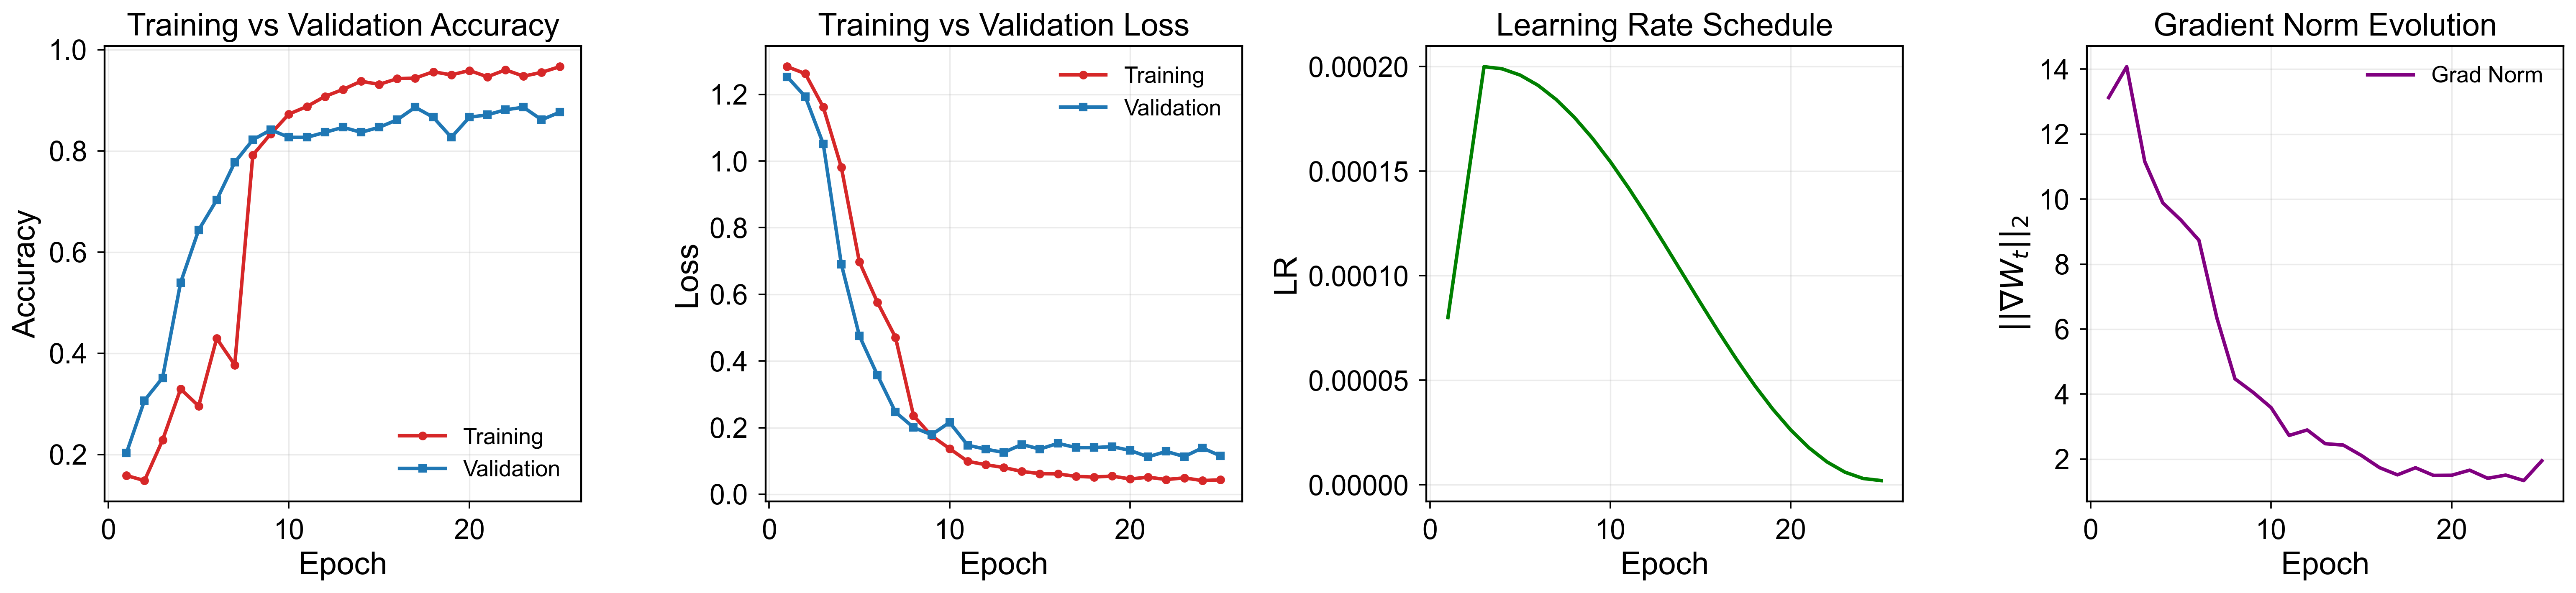

(<Figure size 3120x750 with 4 Axes>,
 array([<Axes: title={'center': 'Training vs Validation Accuracy'}, xlabel='Epoch', ylabel='Accuracy'>,
        <Axes: title={'center': 'Training vs Validation Loss'}, xlabel='Epoch', ylabel='Loss'>,
        <Axes: title={'center': 'Learning Rate Schedule'}, xlabel='Epoch', ylabel='LR'>,
        <Axes: title={'center': 'Gradient Norm Evolution'}, xlabel='Epoch', ylabel='$||\\nabla W_t||_2$'>],
       dtype=object))

In [7]:
%matplotlib inline
%config InlineBackend.figure_format = "retina"

from pathlib import Path
import sys, importlib, torch, time
import pandas as pd

import utils.utils_train as T
import utils.utils_data as D
import utils.utils_model as M
import utils.utils_plot as P

T, D, M, P = map(importlib.reload, [T, D, M, P])

# ================= CONFIG =================
TRAIN_DIR = PROJECT_ROOT / "data" / "dataset_full" / "train"
VAL_DIR   = PROJECT_ROOT / "data" / "dataset_full" / "val"
OUT_DIR   = PROJECT_ROOT / "models" / "effnet_b3_sam"

IMG_SIZE, BATCH_SIZE, EPOCHS = 320, 16, 25
LR, WEIGHT_DECAY, PATIENCE, SEED = 2e-4, 5e-4, 7, 1337

# ================= RUN =================
T.set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

train_loader, val_loader, class_names = D.build_dataloaders(
    TRAIN_DIR, VAL_DIR,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    balanced=True,
    autocrop=True,
    num_workers=0
)

model = M.build_cnn_model(
    model_name="efficientnet_b3",
    num_classes=len(class_names),
    dropout=0.6,
    pretrained=True
)

# ================= TIMER START =================
if torch.cuda.is_available():
    torch.cuda.synchronize()

start_time = time.perf_counter()

history = T.train_sam_mixup_model(
    model, train_loader, val_loader,
    out_dir=OUT_DIR,
    epochs=EPOCHS,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
    patience=PATIENCE,
    device=device,
    save_prefix="best"
)

if torch.cuda.is_available():
    torch.cuda.synchronize()

end_time = time.perf_counter()
# ================= TIMER END =================

OUT_DIR.mkdir(parents=True, exist_ok=True)
pd.DataFrame(history).to_csv(OUT_DIR / "history.csv", index=False)

# ================= PRINT TIME ONLY =================
total_time_s = end_time - start_time
total_time_min = total_time_s / 60
actual_epochs = len(history["val_acc"])
avg_time_per_epoch_s = total_time_s / actual_epochs

print(f"\nBest Validation Accuracy: {max(history['val_acc']) * 100:.2f}%")
print("Saved to:", OUT_DIR)

print("\n========== TRAINING TIME ==========")
print(f"Model                  : EfficientNet-B3")
print(f"Device                 : {device}")
print(f"Epochs actually trained: {actual_epochs}")
print(f"Total training time    : {total_time_min:.2f} min")
print(f"Total training time    : {total_time_s:.2f} s")
print(f"Average time per epoch : {avg_time_per_epoch_s:.2f} s")
print("===================================")

P.plot_training_curves(
    history=history,
    save_path=OUT_DIR / "training_curves_original_colors.png"
)

## Vision Transformer (ViT) version B16 architecture

In [8]:
from pathlib import Path
import sys, importlib, torch, pandas as pd

import utils.utils_train as T
import utils.utils_data as D
import utils.utils_model as M

T, D, M = map(importlib.reload, [T, D, M])

TRAIN_DIR = PROJECT_ROOT / "data" / "dataset_full" / "train"
VAL_DIR   = PROJECT_ROOT / "data" / "dataset_full" / "val"
OUT_DIR   = PROJECT_ROOT / "models" / "vit_fair_clean"

IMG_SIZE, BATCH_SIZE, EPOCHS = 224, 16, 25
LR, WEIGHT_DECAY, PATIENCE, SEED = 3e-5, 1e-4, 7, 1337

torch.set_grad_enabled(True)
T.set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

train_loader, val_loader, class_names = D.build_dataloaders(
    TRAIN_DIR, VAL_DIR,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    balanced=True,
    autocrop=True,
    num_workers=0
)

model = M.build_cnn_model(
    model_name="vit_b16",
    num_classes=len(class_names),
    dropout=0.3,
    pretrained=True
)

history = T.train_standard_classifier(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    out_dir=OUT_DIR,
    epochs=EPOCHS,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
    patience=PATIENCE,
    device=device,
    save_name="vit_best.pt"
)

OUT_DIR.mkdir(parents=True, exist_ok=True)
pd.DataFrame(history).to_csv(OUT_DIR / "history.csv", index=False)

print(f"Best ViT-B16 Accuracy: {max(history['val_acc']) * 100:.2f}%")
print("Saved:", OUT_DIR / "history.csv")

Device: cuda
Epoch 01/25 | Train 22.85% | Val 36.14%
Epoch 02/25 | Train 36.83% | Val 49.50%


/opt/anaconda3/envs/torch/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:198: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch 03/25 | Train 52.81% | Val 57.43%
Epoch 04/25 | Train 63.17% | Val 66.83%
Epoch 05/25 | Train 69.54% | Val 68.81%
Epoch 06/25 | Train 76.28% | Val 72.77%
Epoch 07/25 | Train 81.65% | Val 77.72%
Epoch 08/25 | Train 84.64% | Val 77.23%
Epoch 09/25 | Train 89.01% | Val 81.19%
Epoch 10/25 | Train 92.51% | Val 79.21%
Epoch 11/25 | Train 93.63% | Val 76.73%
Epoch 12/25 | Train 94.51% | Val 81.68%
Epoch 13/25 | Train 96.88% | Val 81.68%
Epoch 14/25 | Train 96.13% | Val 83.66%
Epoch 15/25 | Train 98.00% | Val 81.19%
Epoch 16/25 | Train 98.63% | Val 84.65%
Epoch 17/25 | Train 98.88% | Val 85.64%
Epoch 18/25 | Train 99.13% | Val 84.65%
Epoch 19/25 | Train 99.25% | Val 84.16%
Epoch 20/25 | Train 99.50% | Val 83.17%
Epoch 21/25 | Train 99.50% | Val 83.66%
Epoch 22/25 | Train 99.50% | Val 84.16%
Epoch 23/25 | Train 99.63% | Val 83.17%
Epoch 24/25 | Train 99.88% | Val 83.66%
Early stopping triggered
[SAVED] models/vit_fair_clean/history.csv
Best ViT-B16 Accuracy: 85.64%
Saved: models/vit_fair_

## Extract embeddings from EfficientNet-B3

In [15]:
from utils.utils_feature import extract_cnn_embeddings

DATA_ROOT  = PROJECT_ROOT / "data" / "dataset_full"
CHECKPOINT = PROJECT_ROOT / "models" / "effnet_b3_sam" / "best_by_acc.pt"
OUT_DIR    = PROJECT_ROOT / "models" / "final_models"

result = extract_cnn_embeddings(
    data_root=DATA_ROOT,
    out_dir=OUT_DIR,
    checkpoint=CHECKPOINT,
    img_size=320,
    batch_size=32,
    finetuned=True
)

# Save classes list as JSON
classes_path = PROJECT_ROOT / "models" / "abx_final_tuned" / "classes.json"
with open(classes_path, "w", encoding="utf-8") as f:
    json.dump(result["classes"], f, indent=4)

print("\n================ DONE ================")
print("Saved to:", OUT_DIR)
print("Classes:", result["classes"])
print("Train embeddings shape:", result["train_feats"].shape)
print("Val embeddings shape:", result["val_feats"].shape)

Extracting: 100%|██████████| 7/7 [00:02<00:00,  2.96it/s]


================ DONE ================
Saved to: models/final_models
Classes: ['AMX', 'CHL', 'CIP', 'IBU', 'PAR', 'TET']
Train embeddings shape: (801, 1536)
Val embeddings shape: (202, 1536)


In [16]:
import numpy as np
import json
from pathlib import Path

# ================= CONFIG =================
SRC_DIR = PROJECT_ROOT / "models" / "final_models"
OUT_DIR = PROJECT_ROOT / "models" / "abx_final_tuned"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# input files
TRAIN_FEAT = SRC_DIR / "embeddings_train_finetuned.npy"
TRAIN_LAB  = SRC_DIR / "labels_train_finetuned.npy"
VAL_FEAT   = SRC_DIR / "embeddings_val_finetuned.npy"
VAL_LAB    = SRC_DIR / "labels_val_finetuned.npy"

# output files
OUT_FEAT = OUT_DIR / "features_b3_1536.npy"
OUT_LAB  = OUT_DIR / "labels_b3.npy"

# ================= LOAD =================
X_train = np.load(TRAIN_FEAT).astype(np.float32)
y_train = np.load(TRAIN_LAB).astype(np.int64)

X_val = np.load(VAL_FEAT).astype(np.float32)
y_val = np.load(VAL_LAB).astype(np.int64)

# ================= MERGE =================
X = np.vstack([X_train, X_val]).astype(np.float32)
y = np.concatenate([y_train, y_val]).astype(np.int64)

# ================= SAVE =================
np.save(OUT_FEAT, X)
np.save(OUT_LAB, y)

# save split info
split_info = {
    "n_train": int(len(y_train)),
    "n_val": int(len(y_val)),
    "train_range": [0, int(len(y_train) - 1)],
    "val_range": [int(len(y_train)), int(len(y) - 1)]
}

with open(OUT_DIR / "split_info_from_embeddings.json", "w", encoding="utf-8") as f:
    json.dump(split_info, f, indent=2)

print("Saved:")
print(" -", OUT_FEAT)
print(" -", OUT_LAB)
print(" -", OUT_DIR / "split_info_from_embeddings.json")
print()
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Classes:", np.unique(y))

Saved:
 - models/abx_final_tuned/features_b3_1536.npy
 - models/abx_final_tuned/labels_b3.npy
 - models/abx_final_tuned/split_info_from_embeddings.json

X shape: (1003, 1536)
y shape: (1003,)
Classes: [0 1 2 3 4 5]


In [ ]:
from pathlib import Path
import sys, importlib

import utils.utils_model as M
M = importlib.reload(M)

DATA_DIR = PROJECT_ROOT / "models" / "abx_final_tuned"

df = M.run_table2_ml_benchmark(
    feat_path=DATA_DIR / "features_b3_1536.npy",
    label_path=DATA_DIR / "labels_b3.npy",
    out_csv=DATA_DIR / "table_feats_b3.csv",
    n_splits=10,
    use_scaler=True,
    use_pca=False,
    n_pca=256,
    random_state=1337
)

print("Saved:", DATA_DIR / "table_feats_b3.csv")
df

X: (1003, 1536) | y: (1003,)
Methods: ['RF', 'LR', 'XGB', 'SVM', 'ANN', 'KNN']

========== RF ==========
[RF fold 01] Acc=95.05% | F1=94.91%
[RF fold 02] Acc=98.02% | F1=98.07%
[RF fold 03] Acc=98.02% | F1=98.07%
[RF fold 04] Acc=98.00% | F1=97.94%
[RF fold 05] Acc=94.00% | F1=94.05%
[RF fold 06] Acc=93.00% | F1=92.80%
[RF fold 07] Acc=94.00% | F1=94.27%
[RF fold 08] Acc=96.00% | F1=95.92%
[RF fold 09] Acc=96.00% | F1=96.05%
[RF fold 10] Acc=96.00% | F1=95.84%

========== LR ==========
[LR fold 01] Acc=95.05% | F1=94.70%
[LR fold 02] Acc=98.02% | F1=98.07%
[LR fold 03] Acc=98.02% | F1=98.07%
[LR fold 04] Acc=97.00% | F1=97.04%
[LR fold 05] Acc=93.00% | F1=92.97%


/opt/anaconda3/envs/torch/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/envs/torch/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/envs/torch/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/envs/torch/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: Futur

[LR fold 06] Acc=95.00% | F1=95.12%
[LR fold 07] Acc=92.00% | F1=91.63%
[LR fold 08] Acc=97.00% | F1=96.96%
[LR fold 09] Acc=98.00% | F1=97.97%
[LR fold 10] Acc=95.00% | F1=94.98%

========== XGB ==========


/opt/anaconda3/envs/torch/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/envs/torch/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/envs/torch/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


[XGB fold 01] Acc=94.06% | F1=94.06%
[XGB fold 02] Acc=97.03% | F1=97.00%
[XGB fold 03] Acc=96.04% | F1=96.07%
[XGB fold 04] Acc=98.00% | F1=97.98%
[XGB fold 05] Acc=95.00% | F1=95.05%
[XGB fold 06] Acc=93.00% | F1=93.00%
[XGB fold 07] Acc=93.00% | F1=93.20%
[XGB fold 08] Acc=96.00% | F1=95.92%
[XGB fold 09] Acc=97.00% | F1=97.00%
[XGB fold 10] Acc=95.00% | F1=94.87%

========== SVM ==========
[SVM fold 01] Acc=97.03% | F1=96.97%
[SVM fold 02] Acc=98.02% | F1=98.07%
[SVM fold 03] Acc=97.03% | F1=97.19%
[SVM fold 04] Acc=98.00% | F1=98.03%
[SVM fold 05] Acc=93.00% | F1=92.97%
[SVM fold 06] Acc=94.00% | F1=94.00%
[SVM fold 07] Acc=94.00% | F1=94.28%
[SVM fold 08] Acc=97.00% | F1=96.96%
[SVM fold 09] Acc=98.00% | F1=97.97%
[SVM fold 10] Acc=95.00% | F1=94.94%

========== ANN ==========
[ANN fold 01] Acc=97.03% | F1=96.95%
[ANN fold 02] Acc=97.03% | F1=97.02%
[ANN fold 03] Acc=97.03% | F1=97.19%
[ANN fold 04] Acc=98.00% | F1=97.97%
[ANN fold 05] Acc=93.00% | F1=92.97%
[ANN fold 06] Acc=95.

,Method,Accuracy,Precision,Recall,F1,Acc_std,F1_std
0,RF,0.958089,0.959859,0.957879,0.957929,0.018165,0.018301
1,LR,0.958089,0.958909,0.958302,0.957517,0.021525,0.022511
2,XGB,0.954129,0.955853,0.954403,0.954156,0.017121,0.016771
3,SVM,0.961079,0.962905,0.961240,0.961386,0.019173,0.019040
4,ANN,0.961089,0.962897,0.961505,0.961294,0.016008,0.015841
5,KNN,0.952119,0.954995,0.951477,0.951918,0.019343,0.019818


## Visualize the embeddings using t-SNE

Loaded: X=(1003, 1536), y=(1003,)
Classes: ['AMX', 'CHL', 'CIP', 'IBU', 'PAR', 'TET']
[t-SNE] Computing 106 nearest neighbors...
[t-SNE] Indexed 1003 samples in 0.001s...
[t-SNE] Computed neighbors for 1003 samples in 0.268s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1003
[t-SNE] Computed conditional probabilities for sample 1003 / 1003
[t-SNE] Mean sigma: 12.670367
[t-SNE] KL divergence after 250 iterations with early exaggeration: 64.021210
[t-SNE] KL divergence after 1200 iterations: 0.612947
Saved: models/abx_final_tuned/tsne_features_b3.png


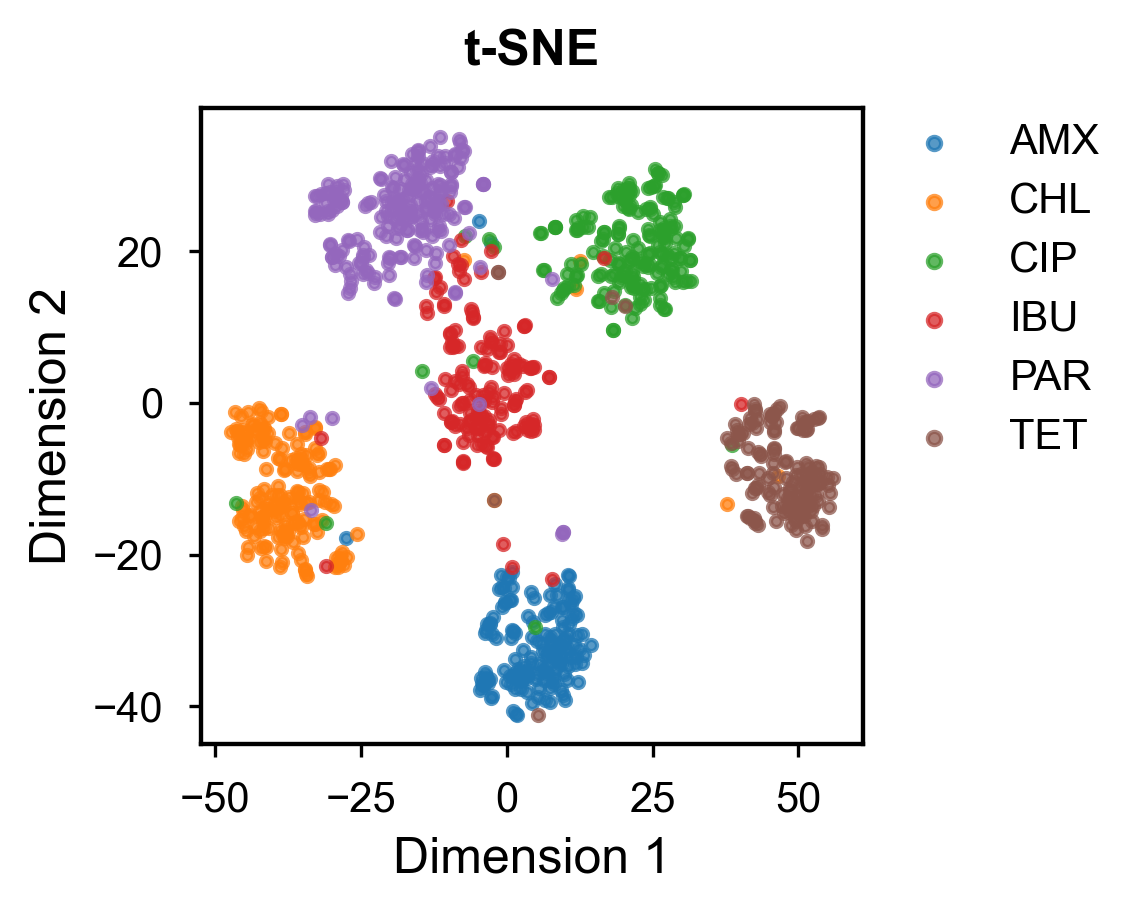

In [17]:
from utils.utils_plot import plot_tsne_from_features

ROOT = PROJECT_ROOT / "models" / "abx_final_tuned"

fig, ax, X_2d = plot_tsne_from_features(
    root=ROOT,
    save_name="tsne_features_b3.png",
    point_size=7,
    alpha=0.75,
    perplexity=35,
    learning_rate=300,
    max_iter=1200,
    random_state=42,
    figsize=(4.0, 3.2),
    title="t-SNE"
)

## Plotting the confusion matrices for the 7 models in the benchmark (CNN, ANN, RF, XGB, SVM, KNN, LR) using the final tuned features.

In [20]:
from pathlib import Path
import sys
import importlib

import utils.utils_model as utils_model
utils_model = importlib.reload(utils_model)

ROOT = PROJECT_ROOT / "models" / "abx_final_tuned"

avg_cms, summary_df = utils_model.run_7model_confusion_matrices(
    root=ROOT,
    run_models=["CNN", "ANN", "RF", "SVM", "KNN", "LR", "XGB"],
    n_folds=10,
    cnn_epochs=30
)


========== CNN ==========
Saved CM CSV -> models/abx_final_tuned/cm_cnn_fold10.csv
CNN  | Acc=0.9192 | Prec=0.9263 | Rec=0.9198

========== ANN ==========
Saved CM CSV -> models/abx_final_tuned/cm_ann_fold10.csv
ANN  | Acc=0.9621 | Prec=0.9639 | Rec=0.9623

========== RF ==========
Saved CM CSV -> models/abx_final_tuned/cm_rf_fold10.csv
RF   | Acc=0.9581 | Prec=0.9601 | Rec=0.9581

========== SVM ==========
Saved CM CSV -> models/abx_final_tuned/cm_svm_fold10.csv
SVM  | Acc=0.9611 | Prec=0.9629 | Rec=0.9612

========== KNN ==========
Saved CM CSV -> models/abx_final_tuned/cm_knn_fold10.csv
KNN  | Acc=0.9521 | Prec=0.9550 | Rec=0.9515

========== LR ==========


/opt/anaconda3/envs/torch/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/envs/torch/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/envs/torch/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/envs/torch/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: Futur

Saved CM CSV -> models/abx_final_tuned/cm_lr_fold10.csv
LR   | Acc=0.9581 | Prec=0.9589 | Rec=0.9583

========== XGB ==========
Saved CM CSV -> models/abx_final_tuned/cm_xgb_fold10.csv
XGB  | Acc=0.9561 | Prec=0.9574 | Rec=0.9559

=== Summary (10-fold CV) ===
Method  Accuracy  Precision   Recall
   CNN  0.919218   0.926294 0.919782
   ANN  0.962099   0.963873 0.962297
    RF  0.958109   0.960134 0.958130
   SVM  0.961079   0.962905 0.961240
   KNN  0.952119   0.954995 0.951477
    LR  0.958089   0.958909 0.958302
   XGB  0.956119   0.957437 0.955885


## Plotting confusion matrices and ROCs for SVM, XGB, and KNN

Loaded: X=(1003, 1536), y=(1003,)
Classes: ['AMX', 'CHL', 'CIP', 'IBU', 'PAR', 'TET']
Running SVM CM/ROC with 10-fold CV...
[SVM fold 01] Acc=97.03% | F1=96.97%
[SVM fold 02] Acc=98.02% | F1=98.07%
[SVM fold 03] Acc=97.03% | F1=97.19%
[SVM fold 04] Acc=98.00% | F1=98.03%
[SVM fold 05] Acc=93.00% | F1=92.97%
[SVM fold 06] Acc=94.00% | F1=94.00%
[SVM fold 07] Acc=94.00% | F1=94.28%
[SVM fold 08] Acc=97.00% | F1=96.96%
[SVM fold 09] Acc=98.00% | F1=97.97%
[SVM fold 10] Acc=95.00% | F1=94.94%

====== CLASSIFICATION REPORT: SVM 10-fold CV ======

              precision    recall  f1-score   support

         AMX     0.9869    0.9805    0.9837       154
         CHL     0.9609    0.9663    0.9636       178
         CIP     0.9548    0.9494    0.9521       178
         IBU     0.9338    0.9400    0.9369       150
         PAR     0.9600    0.9600    0.9600       200
         TET     0.9720    0.9720    0.9720       143

    accuracy                         0.9611      1003
   macro avg     0

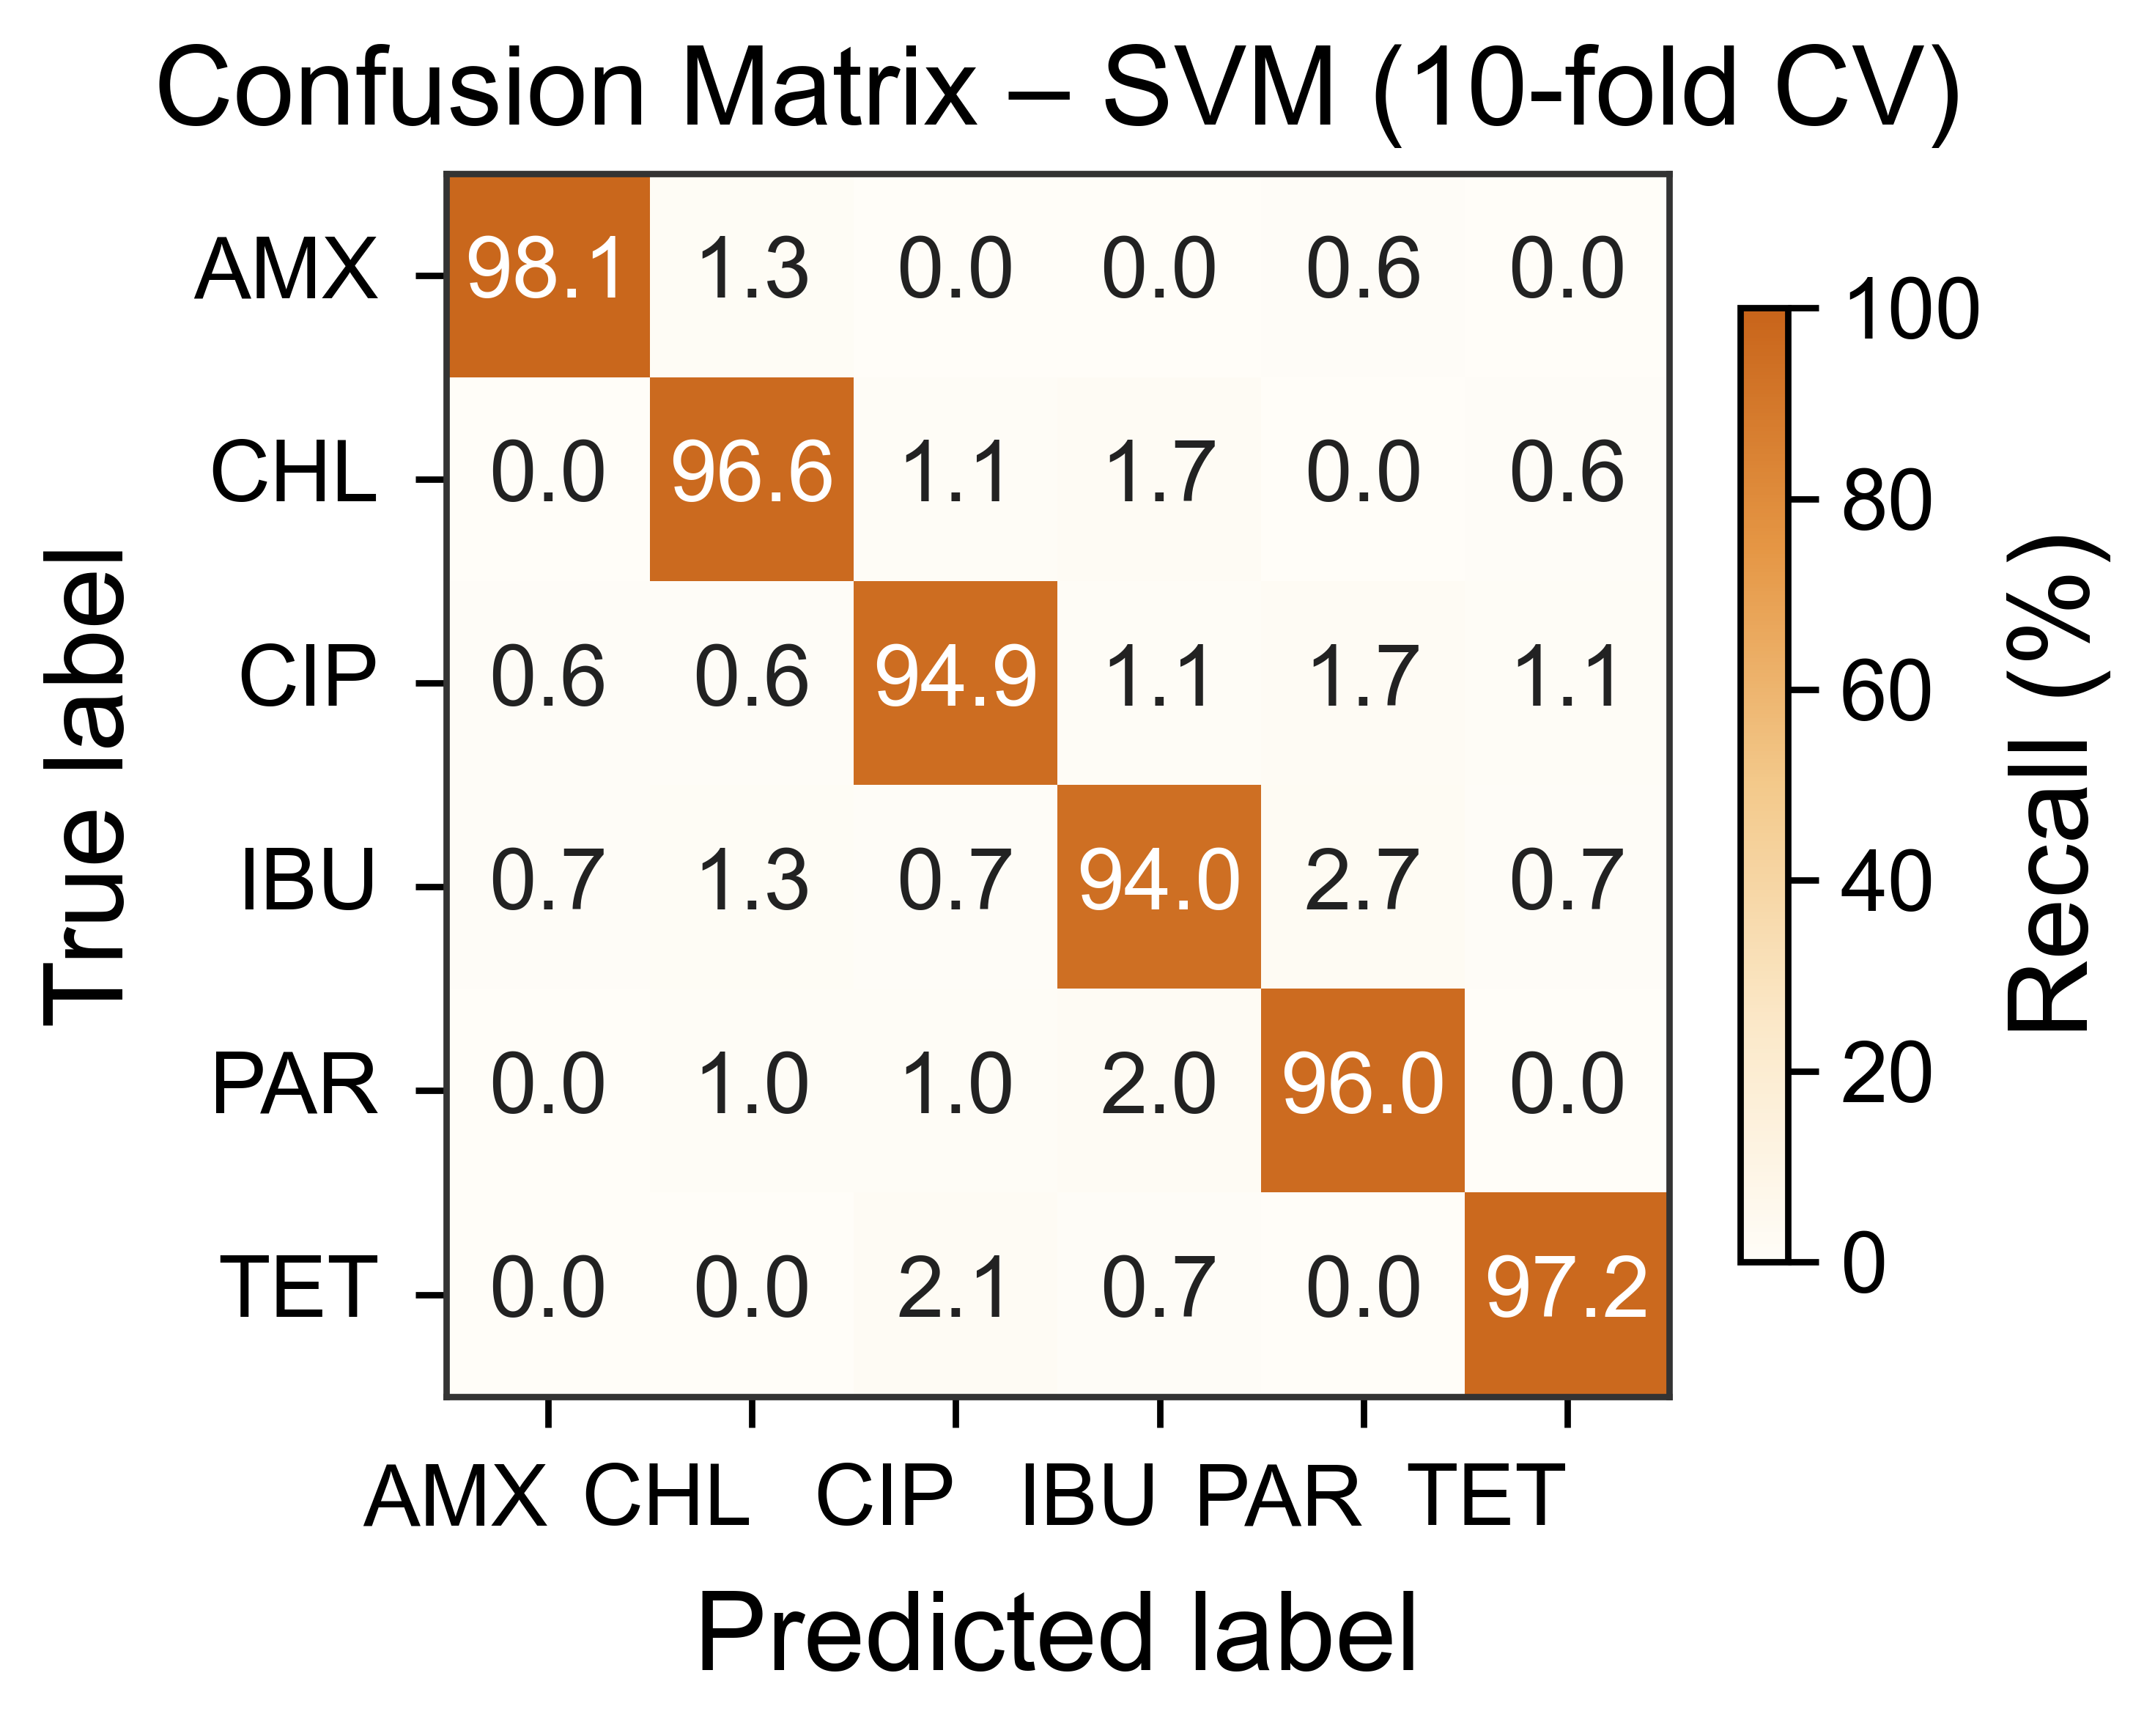

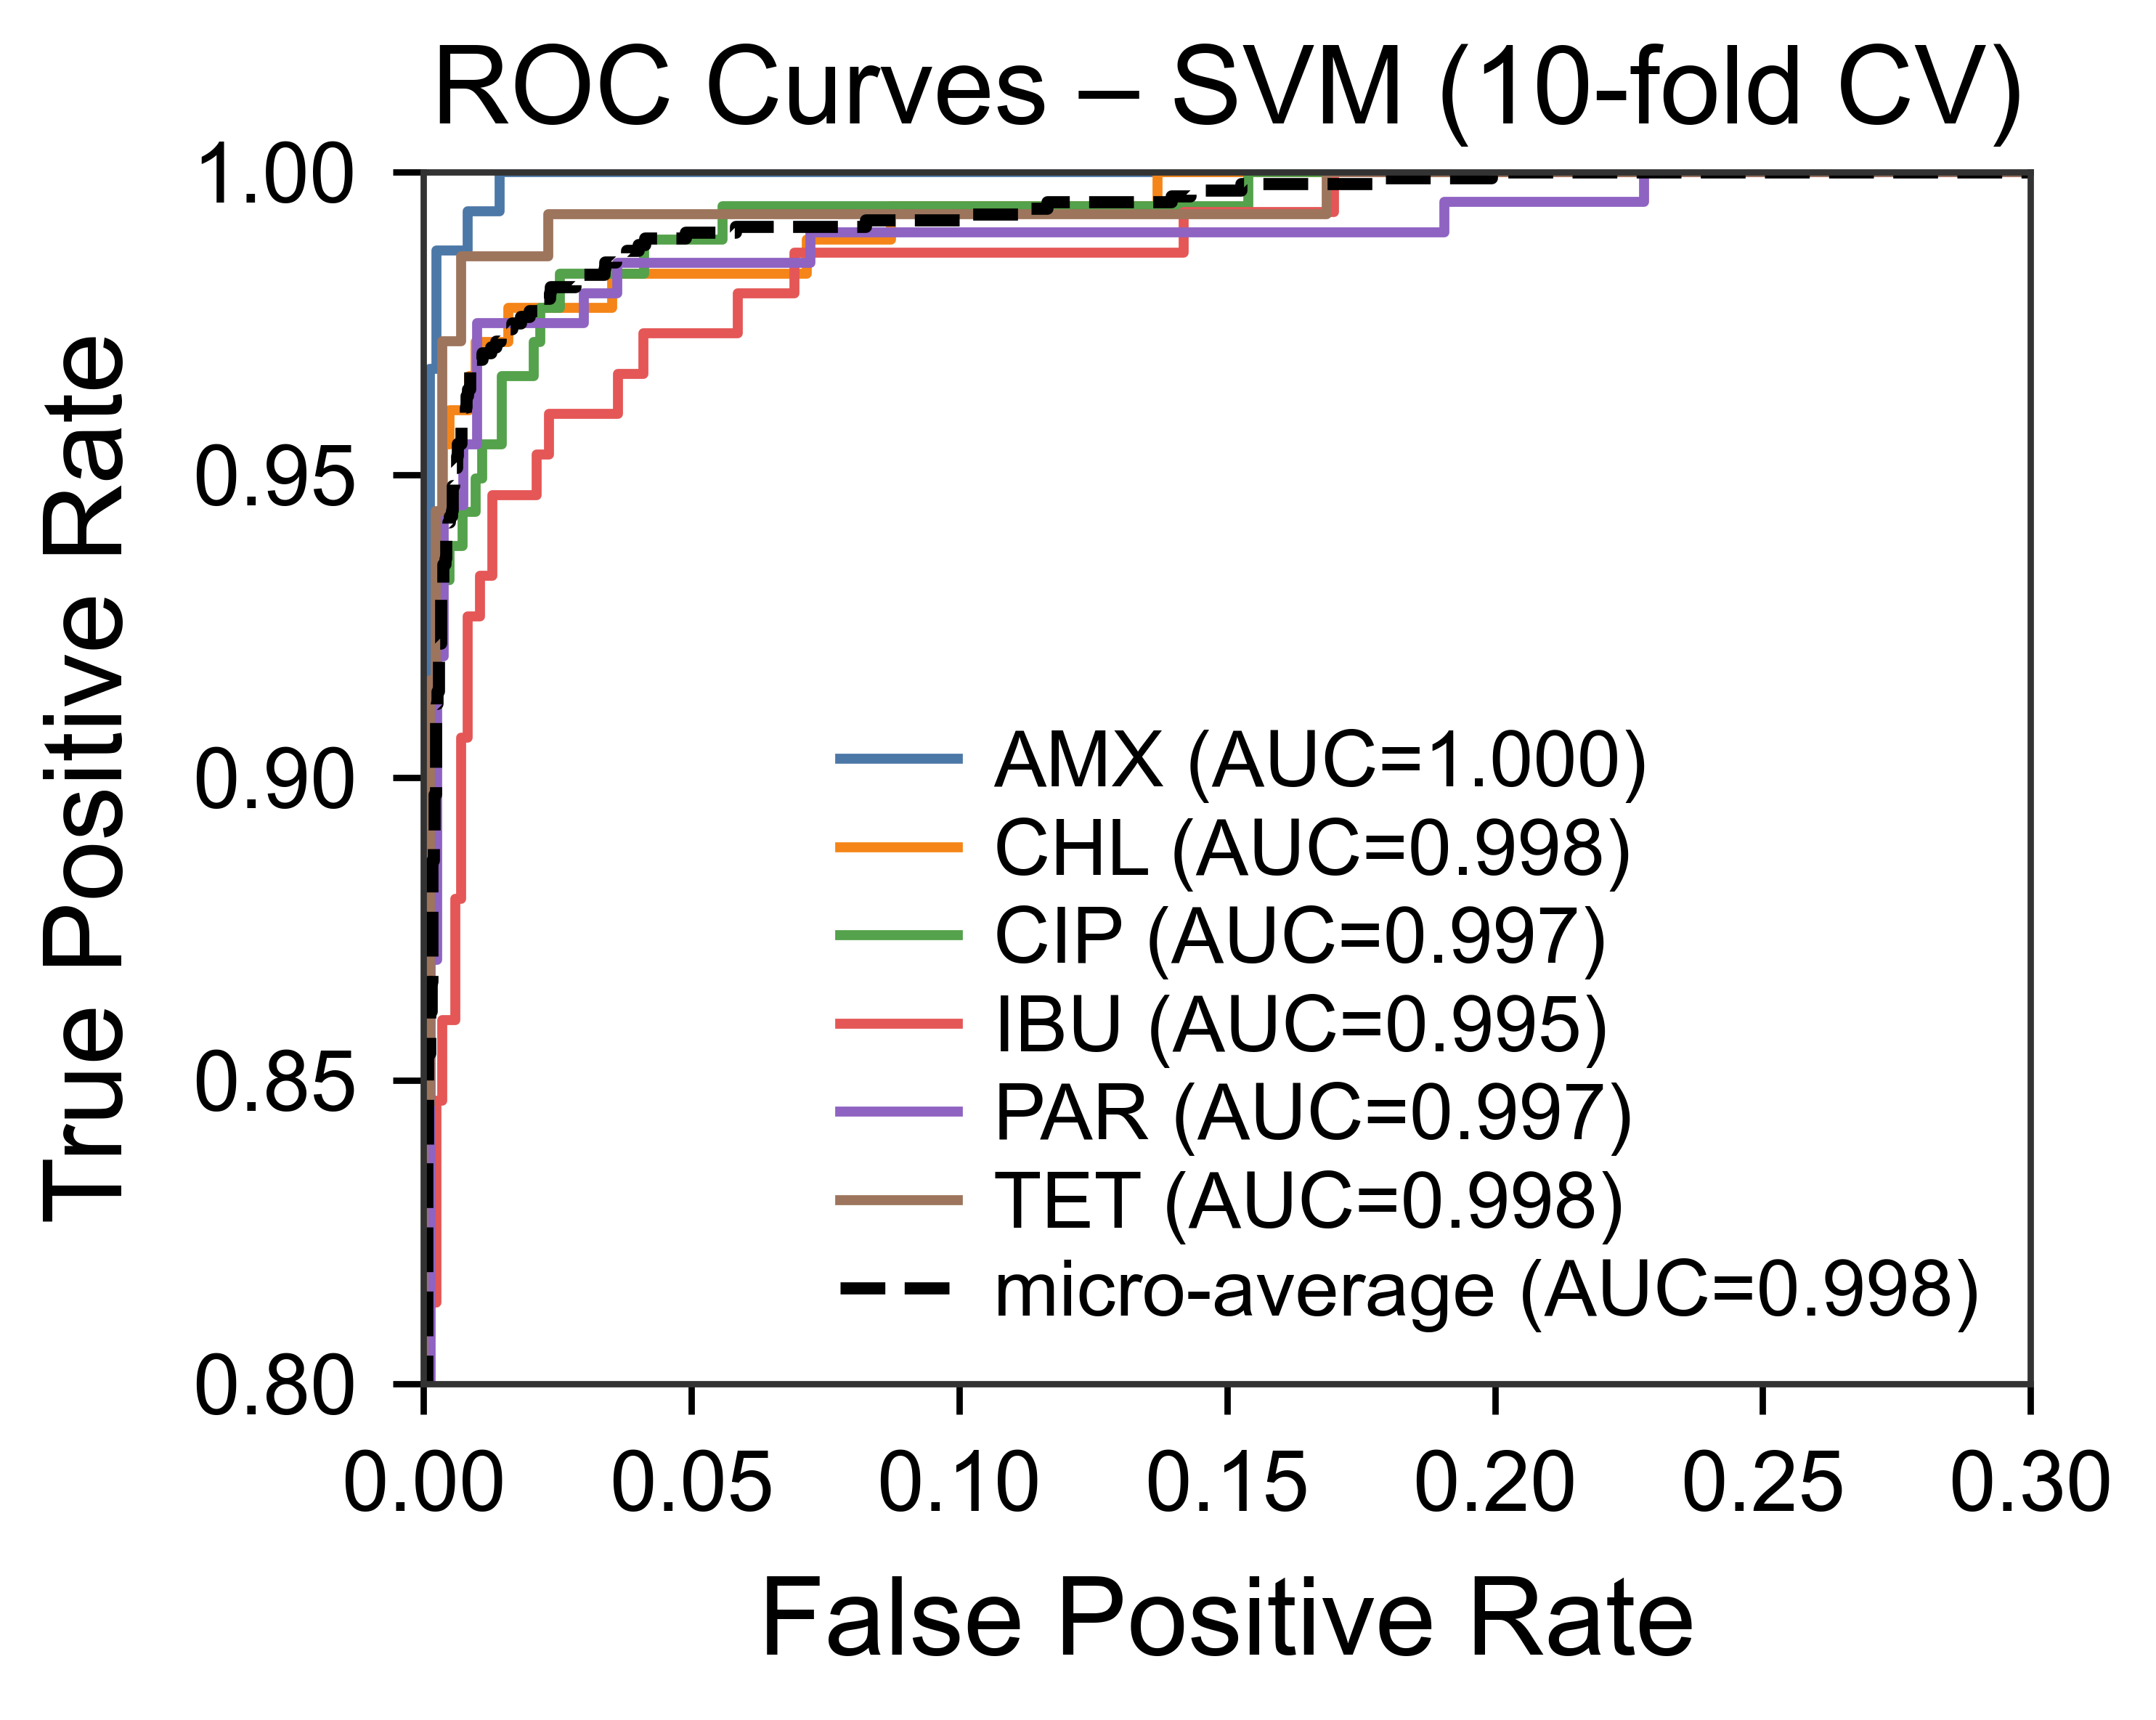


Saved CM CSV  -> models/abx_final_tuned/cm_svm_fold10.csv
Saved ROC CSV -> models/abx_final_tuned/roc_svm_10fold.csv
Saved CM PNG  -> models/abx_final_tuned/cm_svm.png
Saved CM PDF  -> models/abx_final_tuned/cm_svm.pdf
Saved ROC PNG -> models/abx_final_tuned/roc_svm_10fold.png
Saved ROC PDF -> models/abx_final_tuned/roc_svm_10fold.pdf
micro-AUC=0.9977 | macro-AUC=0.9974
Loaded: X=(1003, 1536), y=(1003,)
Classes: ['AMX', 'CHL', 'CIP', 'IBU', 'PAR', 'TET']
Running XGBoost CM/ROC with 10-fold CV...
[XGBoost fold 01] Acc=95.05% | F1=94.77%
[XGBoost fold 02] Acc=97.03% | F1=97.00%
[XGBoost fold 03] Acc=96.04% | F1=96.07%
[XGBoost fold 04] Acc=99.00% | F1=98.93%
[XGBoost fold 05] Acc=94.00% | F1=93.98%
[XGBoost fold 06] Acc=93.00% | F1=93.00%
[XGBoost fold 07] Acc=93.00% | F1=93.20%
[XGBoost fold 08] Acc=96.00% | F1=95.92%
[XGBoost fold 09] Acc=97.00% | F1=97.00%
[XGBoost fold 10] Acc=96.00% | F1=95.84%

====== CLASSIFICATION REPORT: XGBoost 10-fold CV ======

              precision    rec

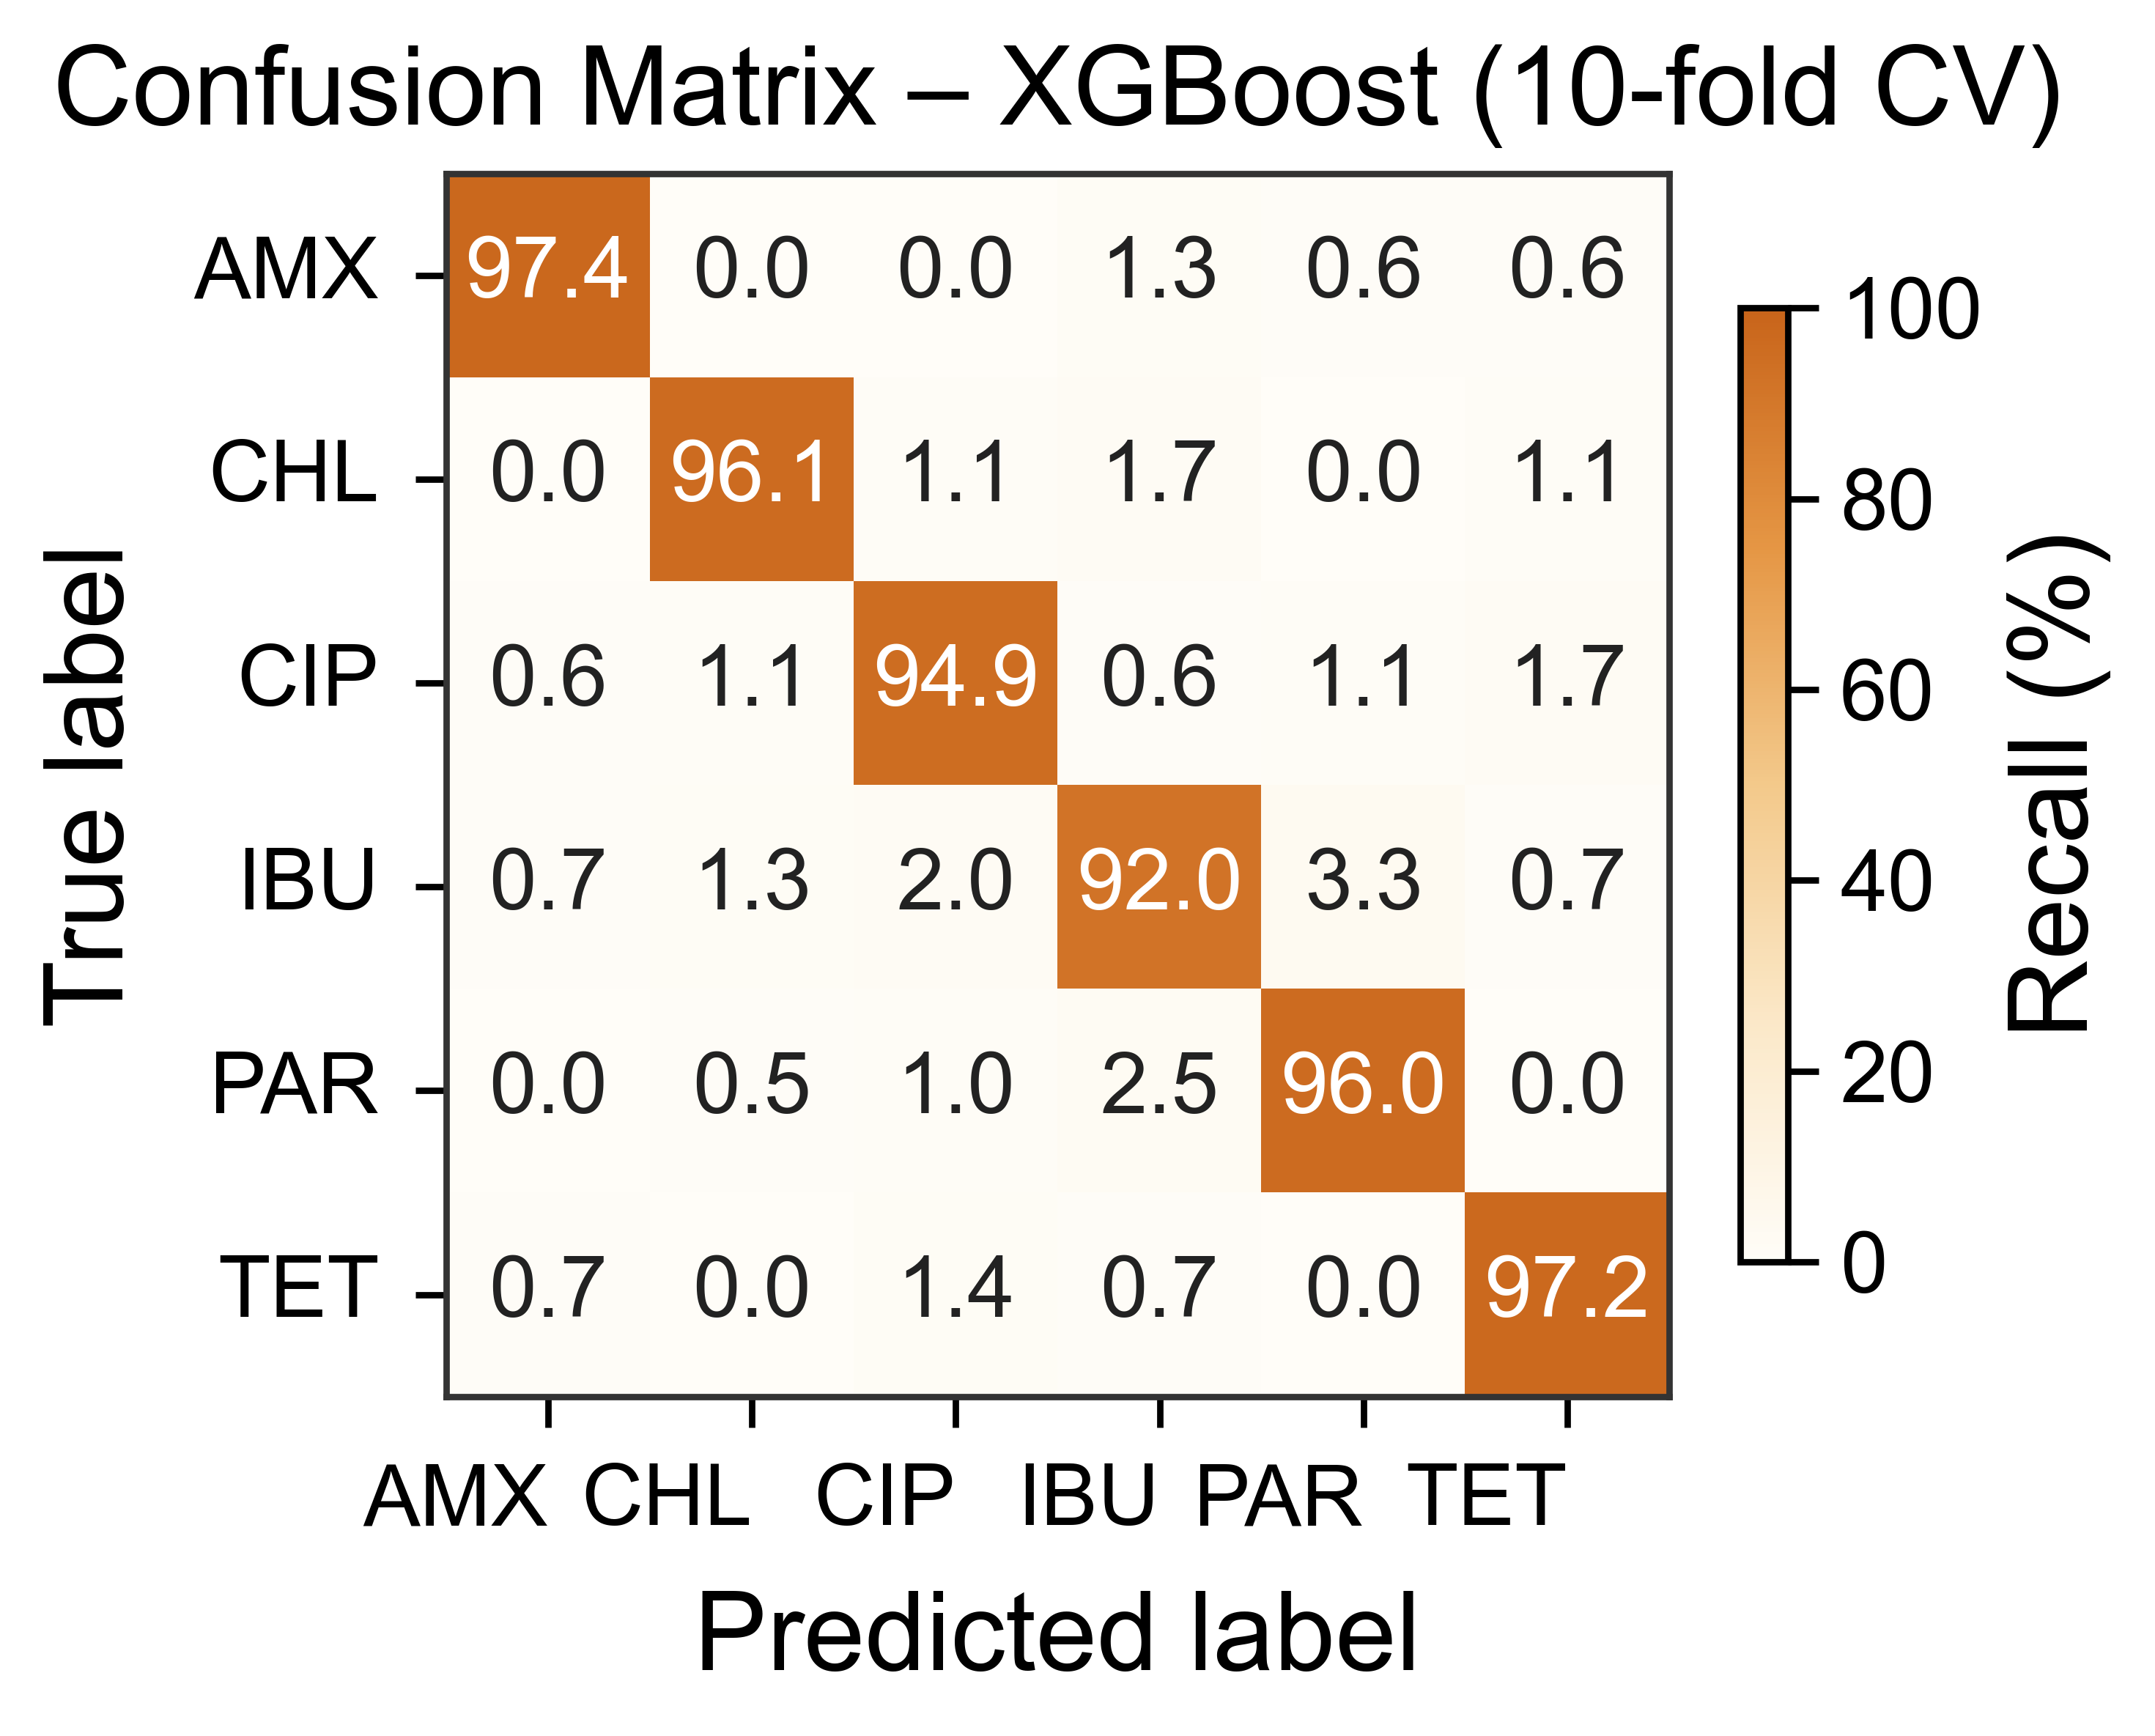

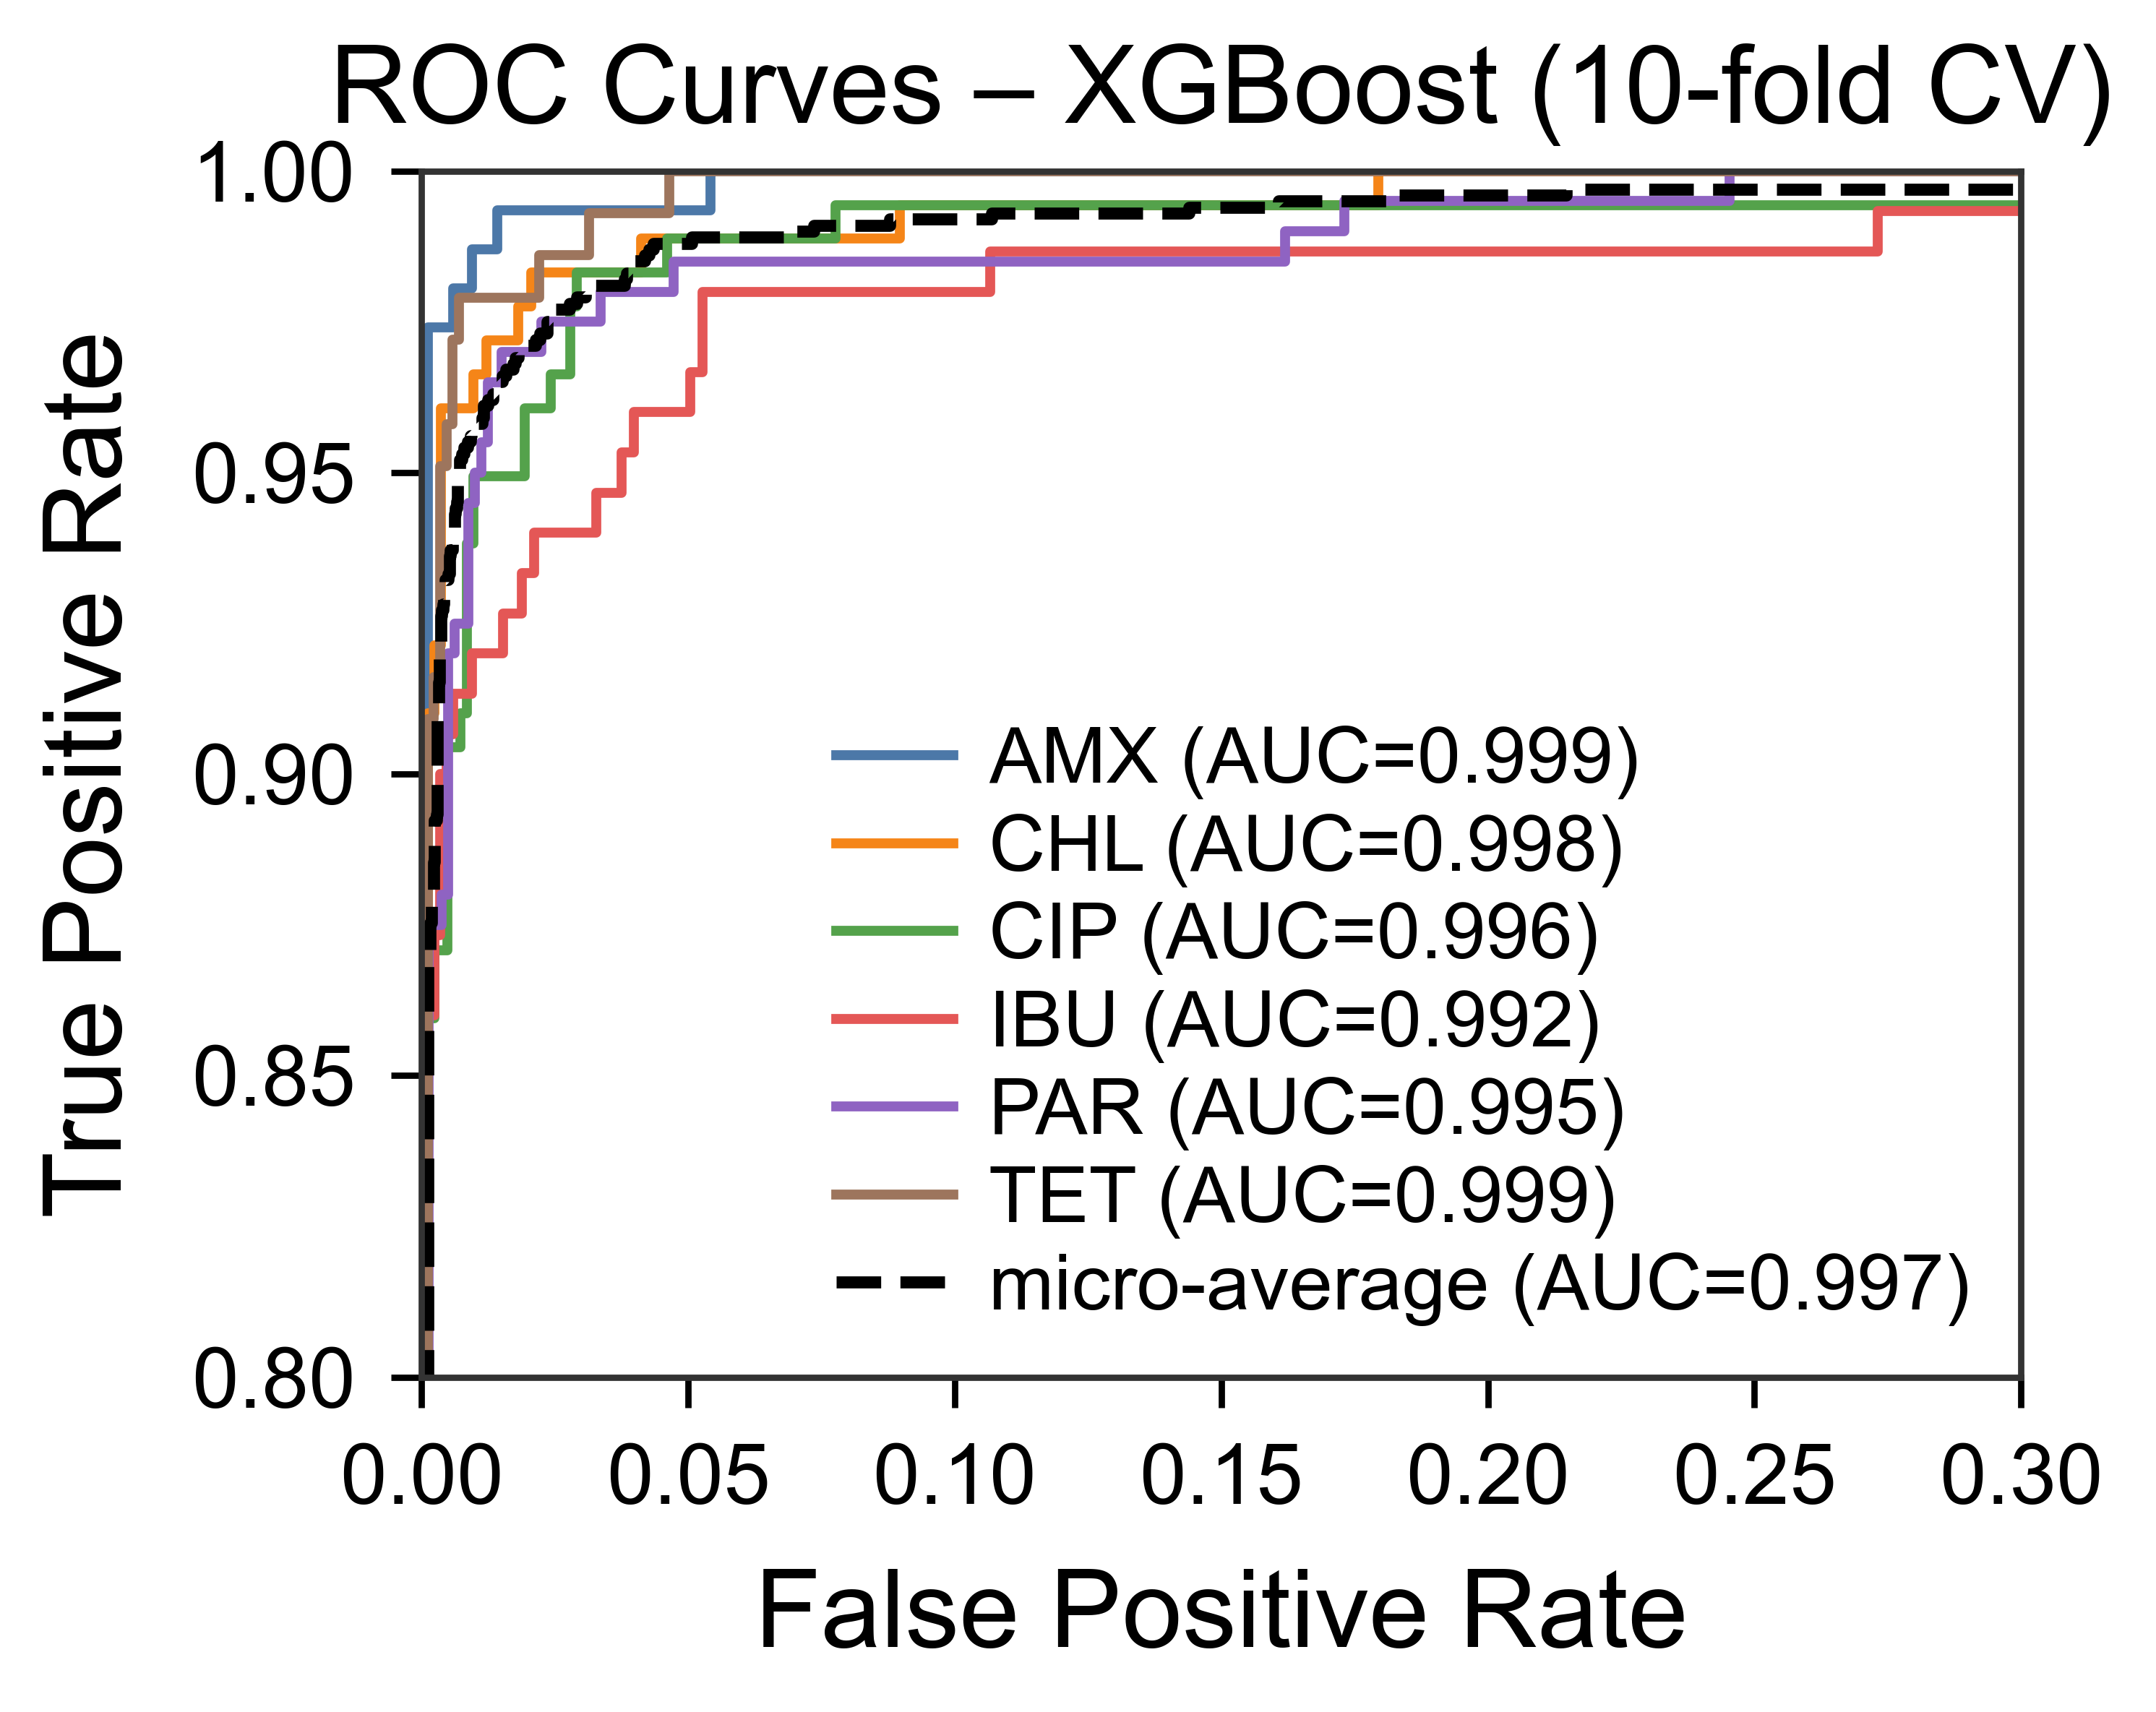


Saved CM CSV  -> models/abx_final_tuned/cm_xgb_fold10.csv
Saved ROC CSV -> models/abx_final_tuned/roc_xgb_auc.csv
Saved CM PNG  -> models/abx_final_tuned/cm_xgb.png
Saved CM PDF  -> models/abx_final_tuned/cm_xgb.pdf
Saved ROC PNG -> models/abx_final_tuned/roc_xgb.png
Saved ROC PDF -> models/abx_final_tuned/roc_xgb.pdf
micro-AUC=0.9965 | macro-AUC=0.9965
Loaded: X=(1003, 1536), y=(1003,)
Classes: ['AMX', 'CHL', 'CIP', 'IBU', 'PAR', 'TET']
Running KNN CM/ROC with 10-fold CV...
[KNN fold 01] Acc=94.06% | F1=94.03%
[KNN fold 02] Acc=96.04% | F1=96.07%
[KNN fold 03] Acc=98.02% | F1=98.07%
[KNN fold 04] Acc=96.00% | F1=96.15%
[KNN fold 05] Acc=94.00% | F1=93.98%
[KNN fold 06] Acc=93.00% | F1=92.72%
[KNN fold 07] Acc=92.00% | F1=92.20%
[KNN fold 08] Acc=98.00% | F1=97.97%
[KNN fold 09] Acc=96.00% | F1=96.09%
[KNN fold 10] Acc=96.00% | F1=95.95%

====== CLASSIFICATION REPORT: KNN 10-fold CV ======

              precision    recall  f1-score   support

         AMX     0.9620    0.9870    0.9

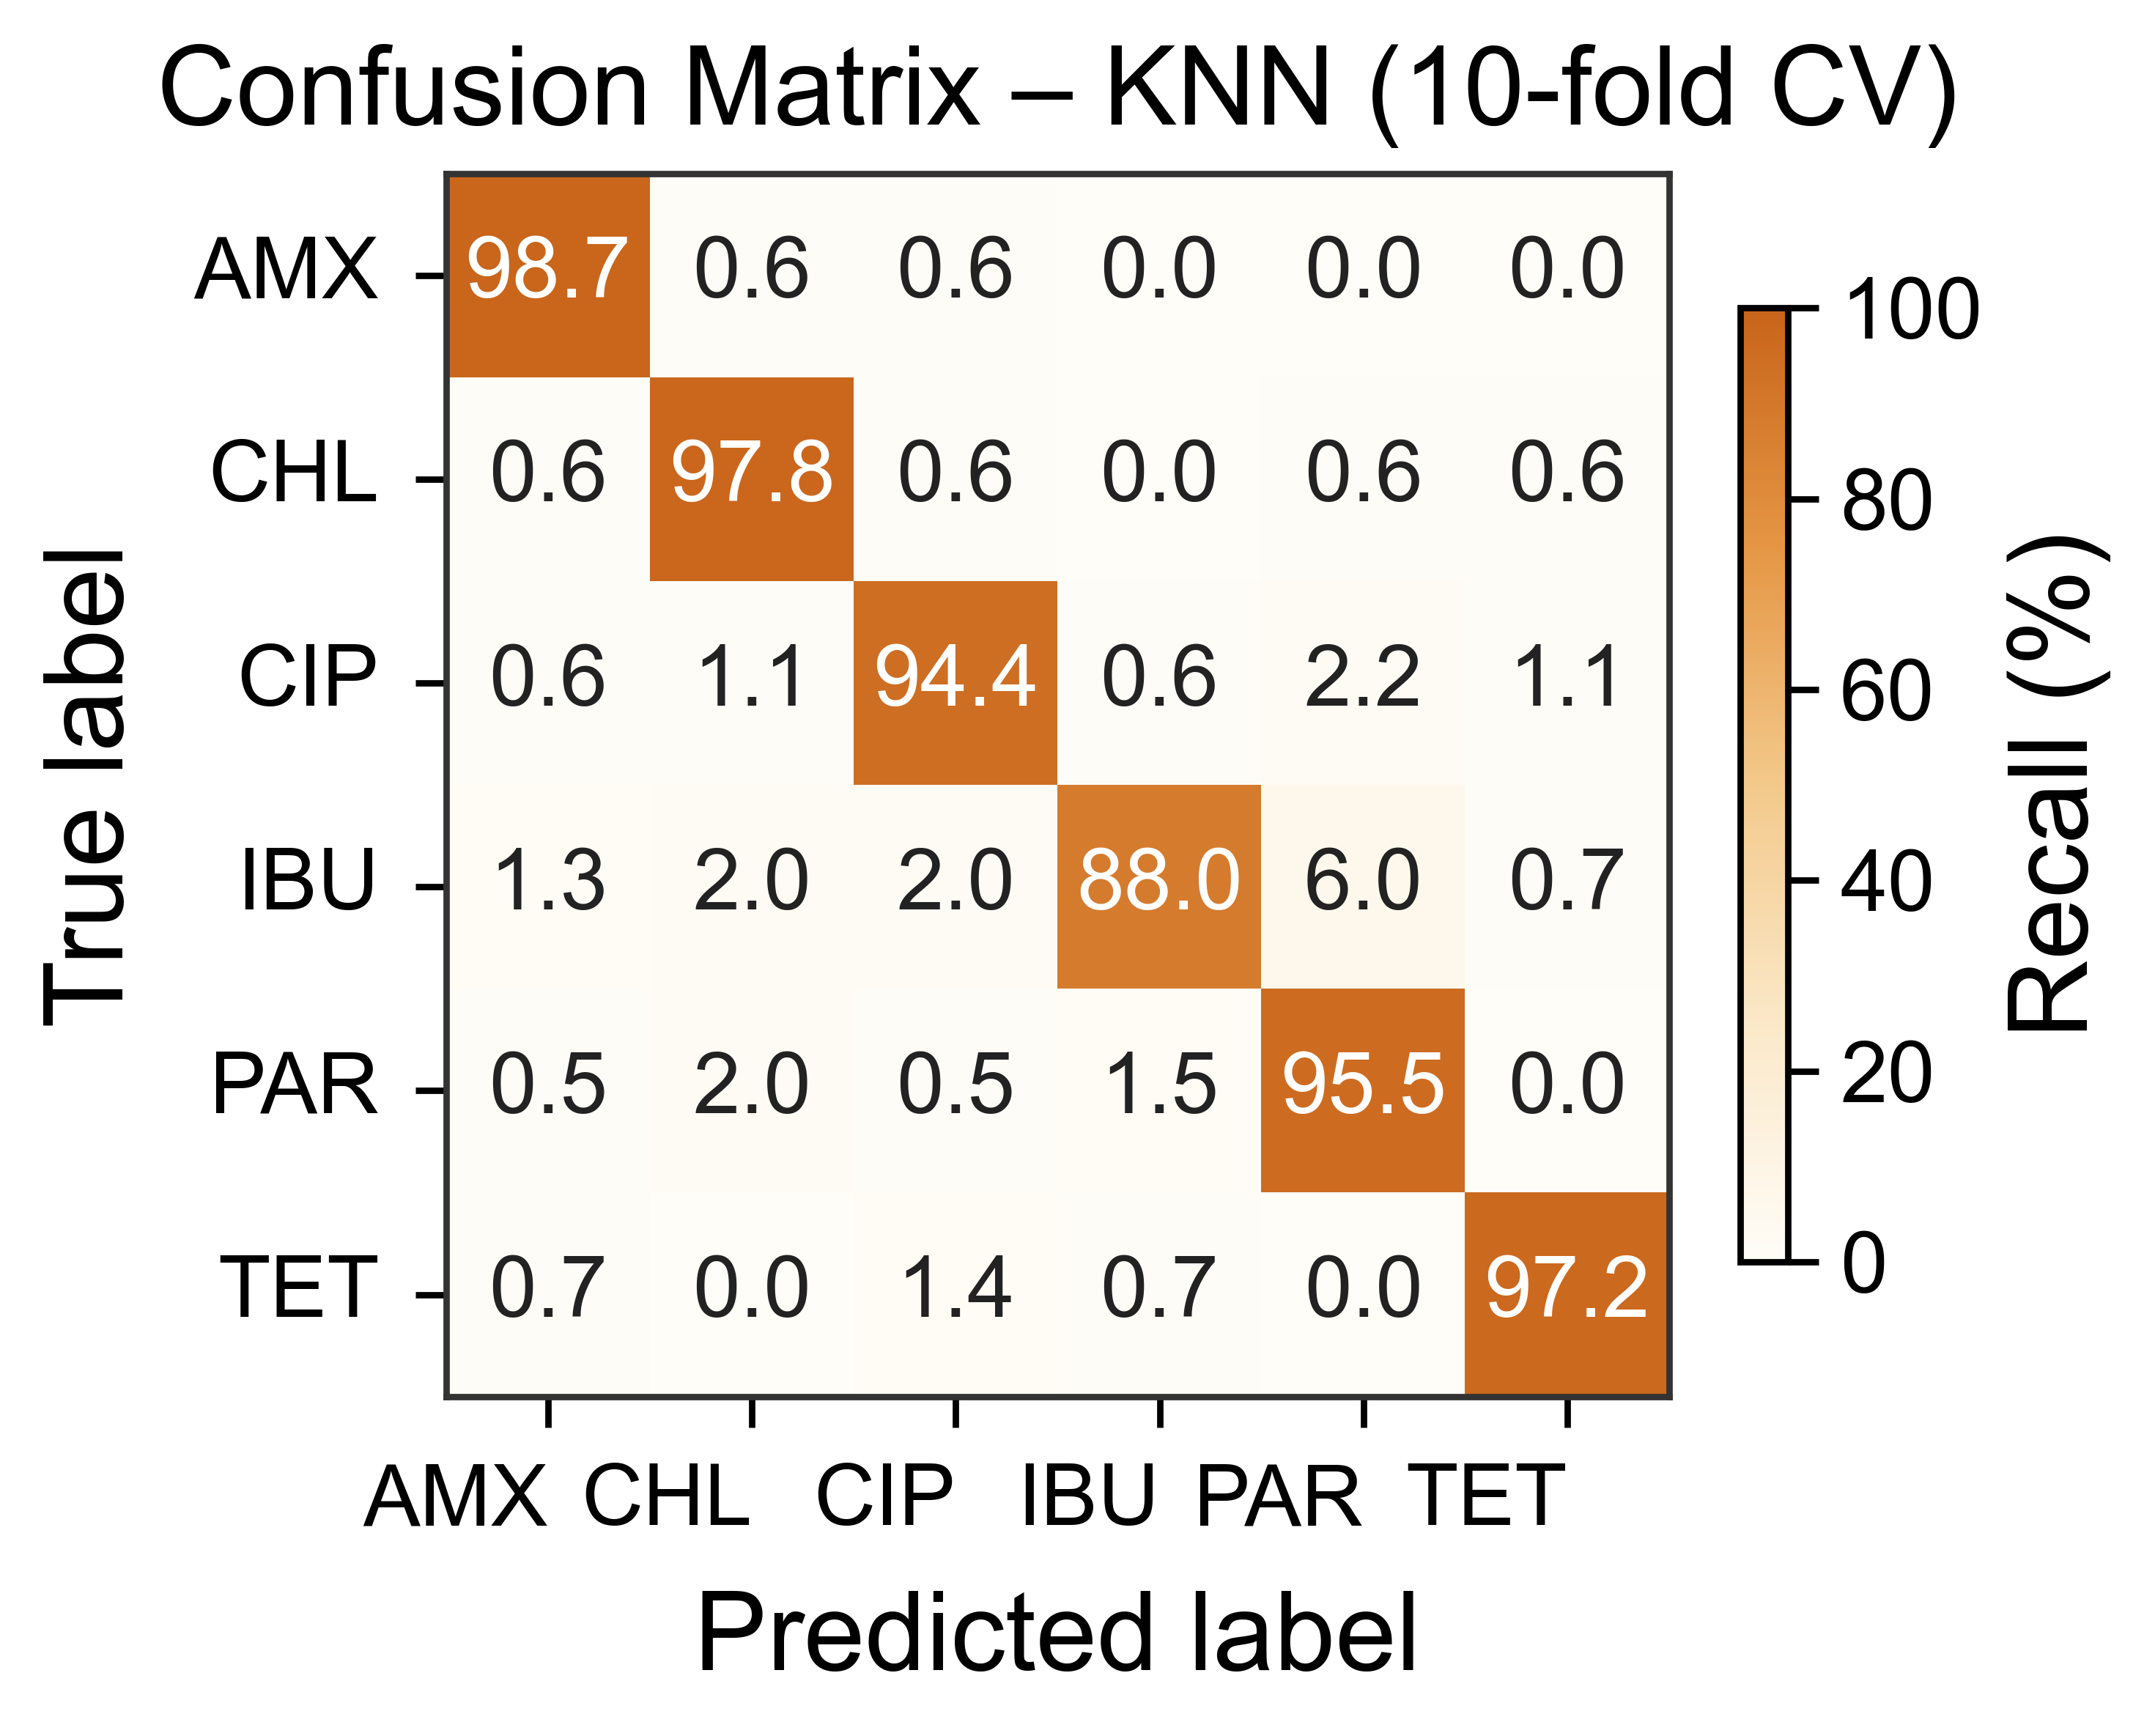

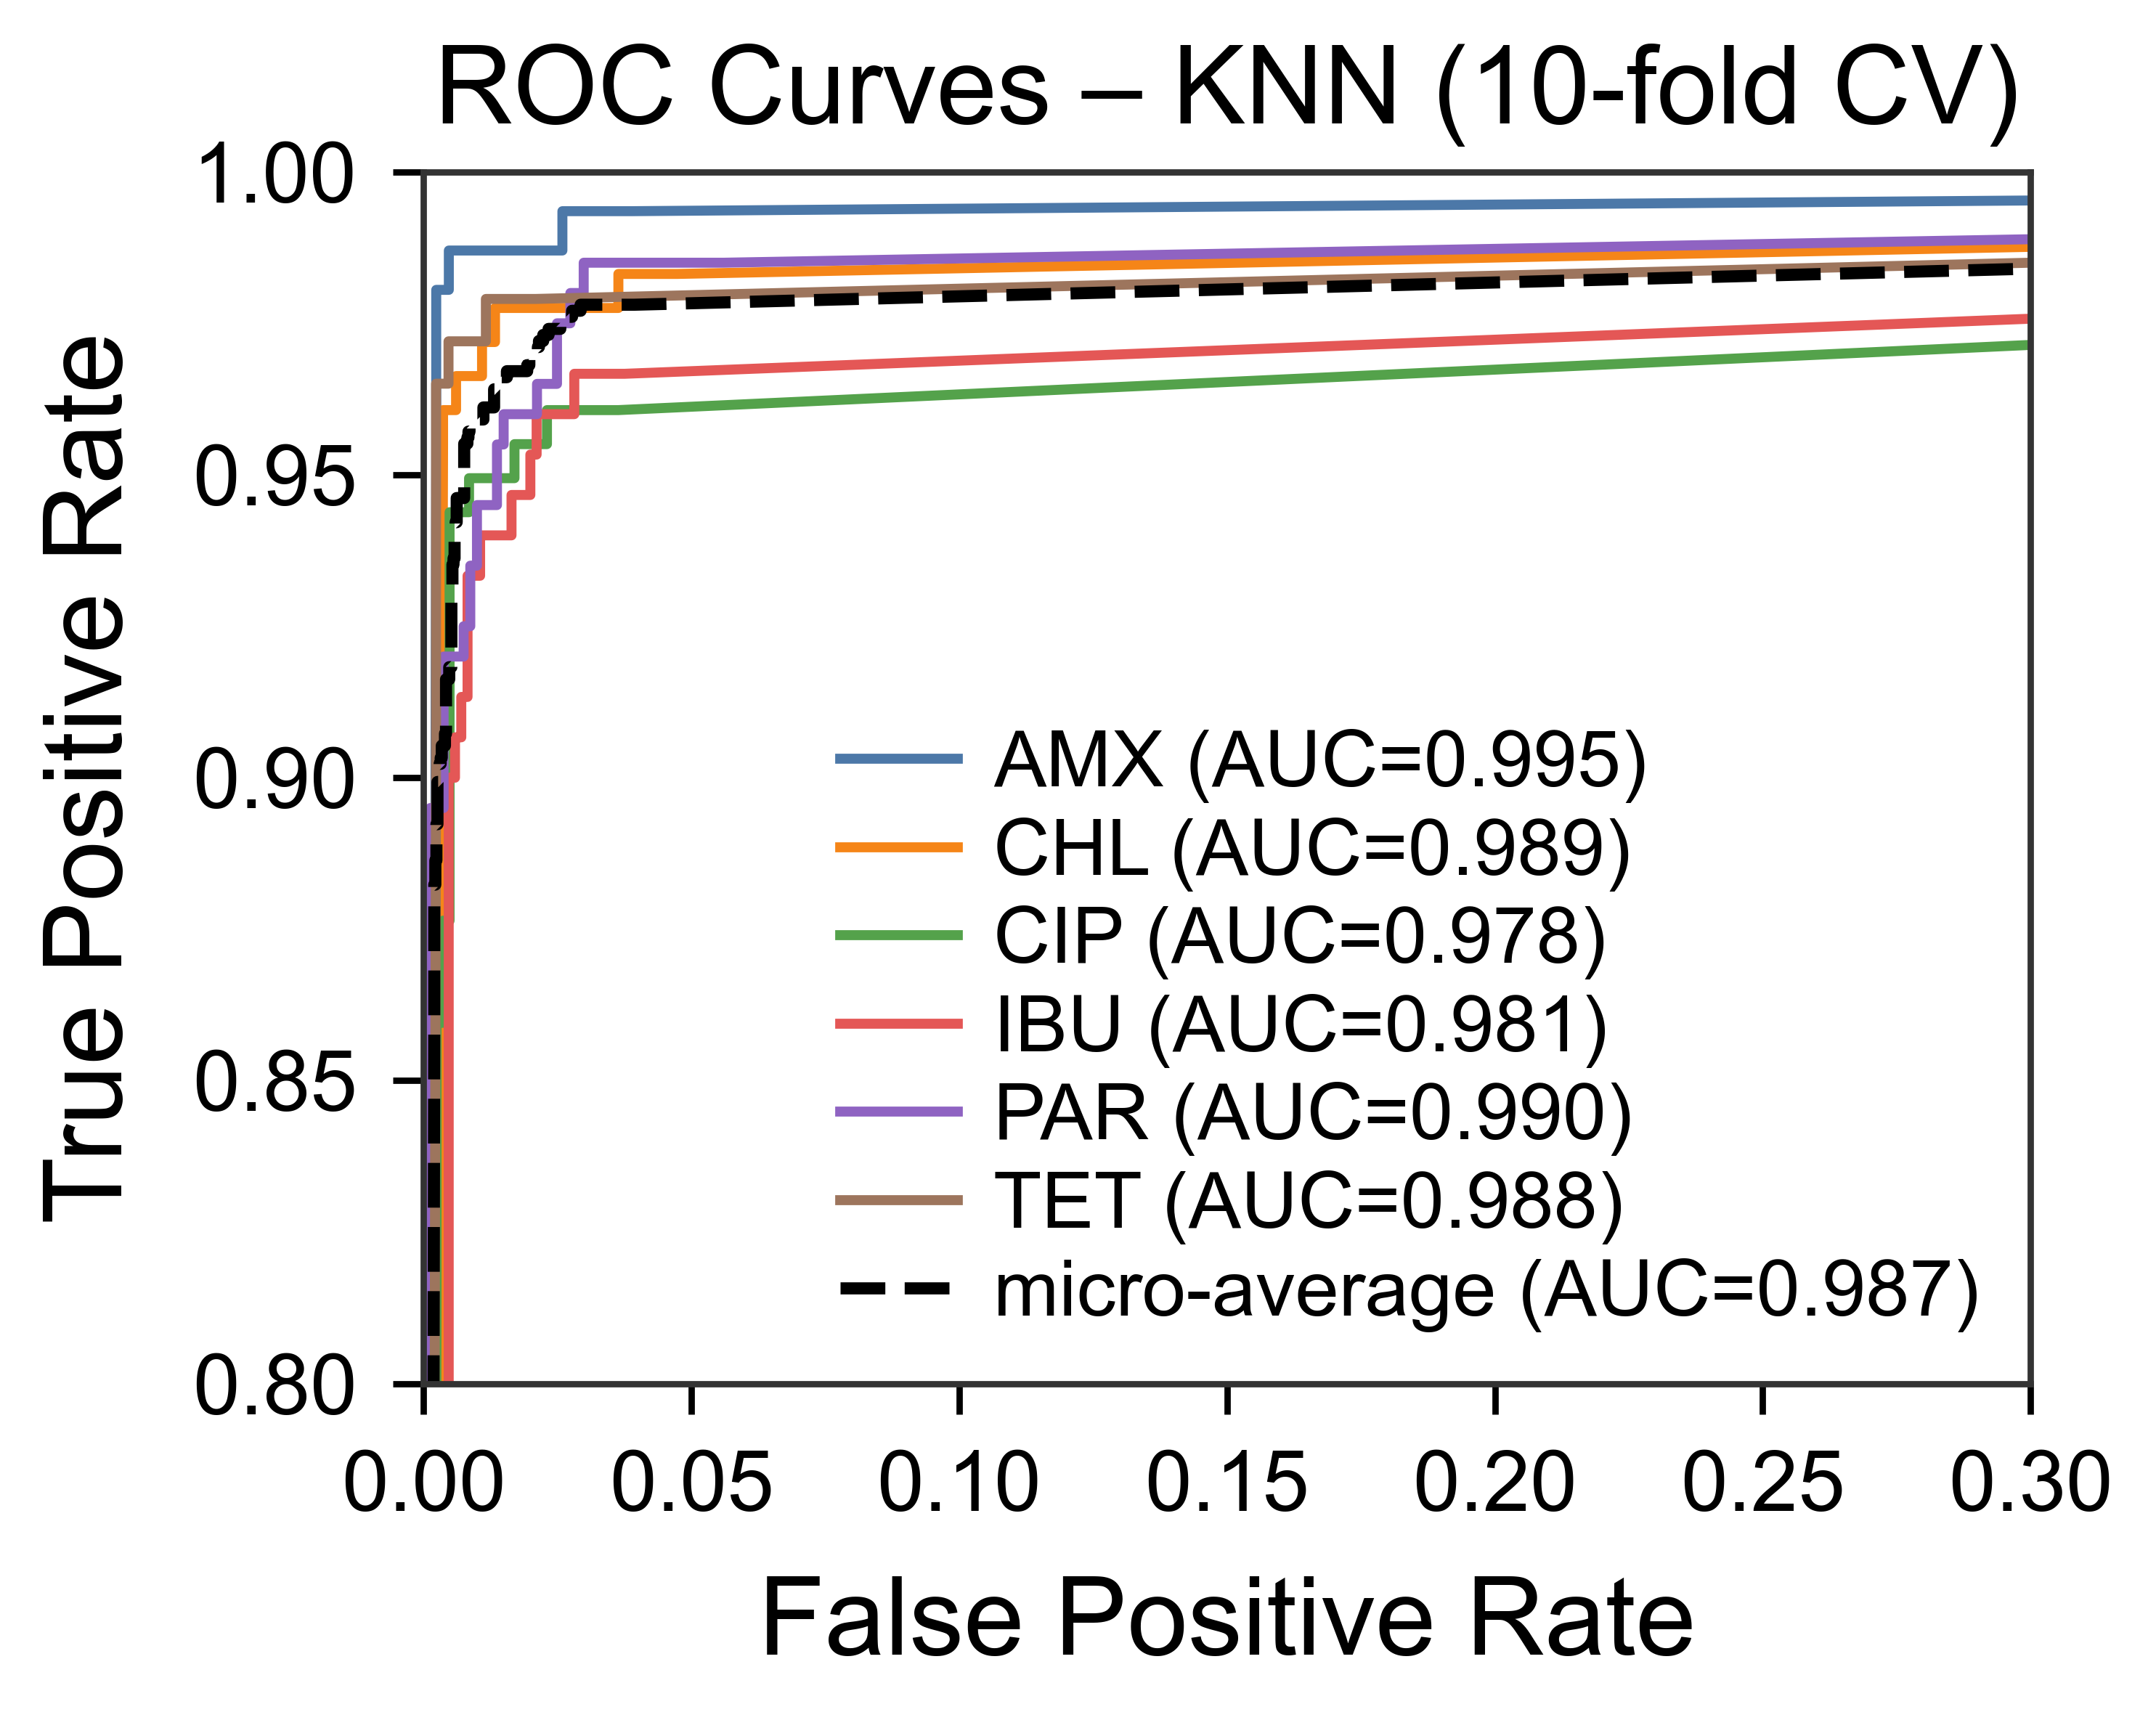


Saved CM CSV  -> models/abx_final_tuned/cm_knn_fold10_sum.csv
Saved CM CSV alias -> models/abx_final_tuned/cm_knn_fold10.csv
Saved ROC CSV -> models/abx_final_tuned/roc_knn_10fold.csv
Saved CM PNG  -> models/abx_final_tuned/cm_knn.png
Saved CM PDF  -> models/abx_final_tuned/cm_knn.pdf
Saved ROC PNG -> models/abx_final_tuned/roc_knn_10fold.png
Saved ROC PDF -> models/abx_final_tuned/roc_knn_10fold.pdf
micro-AUC=0.9870 | macro-AUC=0.9869


In [26]:

import importlib
import utils.utils_plot as P

P = importlib.reload(P)

ROOT = PROJECT_ROOT / "models" / "abx_final_tuned"

svm_result = P.run_svm_cm_roc_10fold(
    root=ROOT,
    plot=True,
    show=True,
)

xgb_result = P.run_xgb_cm_roc_10fold(
    root=ROOT,
    plot=True,
    show=True,
)

knn_result = P.run_knn_cm_roc_10fold(
    root=ROOT
)

In [24]:
from pathlib import Path
import sys
import importlib
import string
import matplotlib.pyplot as plt
from matplotlib.text import Text

# Import sạch utils_plot
importlib.invalidate_caches()
sys.modules.pop("utils.utils_plot", None)
P = importlib.import_module("utils.utils_plot")

# ============================================================
# DATA
# ============================================================

order = (
    "CNN",
    "ANN",
    "RF",
    "XGB",
    "SVM",
    "KNN",
    "LR",
)

csv_map = {
    "CNN": ROOT / "cm_cnn_fold10.csv",
    "ANN": ROOT / "cm_ann_fold10.csv",
    "RF":  ROOT / "cm_rf_fold10.csv",
    "XGB": ROOT / "cm_xgb_fold10.csv",
    "SVM": ROOT / "cm_svm_fold10.csv",
    "KNN": ROOT / "cm_knn_fold10_sum.csv",
    "LR":  ROOT / "cm_lr_fold10.csv",
}


# ============================================================
# DRAW ORIGINAL CONFUSION PANEL
# ============================================================

fig, _ = P.plot_confusion_panel_from_csv(
    csv_map=csv_map,
    class_file=ROOT / "classes.json",
    order=order,
    out_fig=None,
    out_pdf=None,
    out_svg=None,
    show=False,
)


# ============================================================
# FIND THE 7 CM AXES
# ============================================================

axes = [
    ax for ax in fig.axes
    if any(model in ax.get_title() for model in order)
][:7]


# ============================================================
# FORCE ALL TEXT TO ARIAL
# ============================================================

for t in fig.findobj(match=Text):
    t.set_fontfamily("Arial")


# ============================================================
# REMOVE ORIGINAL TITLES
# ============================================================

for ax in axes:
    ax.set_title("")


# ============================================================
# PANEL LETTERS + MODEL TITLES
# a/b/c... bold
# CNN/ANN/... regular
# Same row, like reference image
# ============================================================

fig.canvas.draw()
renderer = fig.canvas.get_renderer()

PANEL_FS = 22
TITLE_FS = 22

HEADER_GAP_Y = 0.012
LETTER_GAP_X = 0.012

for i, (ax, model) in enumerate(zip(axes, order)):

    pos = ax.get_position()

    # Find the true left edge of y tick labels
    boxes = [
        tick.get_window_extent(renderer=renderer)
        for tick in ax.get_yticklabels()
        if tick.get_text().strip()
    ]

    if boxes:
        left_px = min(box.x0 for box in boxes)
        x_left = fig.transFigure.inverted().transform((left_px, 0))[0]
    else:
        x_left = pos.x0 - 0.04

    # Same y-position for letter and model title
    header_y = pos.y1 + HEADER_GAP_Y

    # Panel letter
    fig.text(
        x_left - LETTER_GAP_X,
        header_y,
        string.ascii_lowercase[i],
        fontsize=PANEL_FS,
        fontfamily="Arial",
        fontweight="bold",
        color="black",
        ha="left",
        va="bottom",
    )

    # Model title
    fig.text(
        (pos.x0 + pos.x1) / 2,
        header_y,
        model,
        fontsize=TITLE_FS,
        fontfamily="Arial",
        fontweight="normal",
        color="black",
        ha="center",
        va="bottom",
    )


# ============================================================
# SAVE
# ============================================================

OUT_PNG = ROOT / "confusion_final.png"
OUT_PDF = ROOT / "confusion_final.pdf"
OUT_SVG = ROOT / "confusion_final.svg"

fig.savefig(
    OUT_PNG,
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.03,
    facecolor="white",
)

fig.savefig(
    OUT_PDF,
    bbox_inches="tight",
    pad_inches=0.03,
    facecolor="white",
)

fig.savefig(
    OUT_SVG,
    bbox_inches="tight",
    pad_inches=0.03,
    facecolor="white",
)

plt.show()

print("PNG:", OUT_PNG)
print("PDF:", OUT_PDF)
print("SVG:", OUT_SVG)

PNG: models/abx_final_tuned/confusion_final.png
PDF: models/abx_final_tuned/confusion_final.pdf
SVG: models/abx_final_tuned/confusion_final.svg


In [27]:
import json
import numpy as np

ROOT = PROJECT_ROOT / "models" / "abx_final_tuned"

with open(ROOT / "split_info_from_embeddings.json", "r", encoding="utf-8") as f:
    split_info = json.load(f)

n_train = split_info["n_train"]
n_val   = split_info["n_val"]

idx_train = np.arange(0, n_train)
idx_val   = np.arange(n_train, n_train + n_val)

overlap = set(idx_train) & set(idx_val)

print(f"Matched train indices: {len(idx_train)}")
print(f"Matched val   indices: {len(idx_val)}")
print(f"Overlap indices: {len(overlap)}")
print("Train range:", idx_train[0], "→", idx_train[-1])
print("Val range  :", idx_val[0], "→", idx_val[-1])

Matched train indices: 801
Matched val   indices: 202
Overlap indices: 0
Train range: 0 → 800
Val range  : 801 → 1002


In [28]:
import json
import numpy as np

ROOT = PROJECT_ROOT / "models" / "abx_final_tuned"

X = np.load(ROOT / "features_b3_1536.npy").astype(np.float32)
split = json.load(open(ROOT / "split_info_from_embeddings.json", "r", encoding="utf-8"))

idx_train = np.arange(split["n_train"])
idx_val   = np.arange(split["n_train"], split["n_train"] + split["n_val"])

OUT_IDX = ROOT / "cv_indices_from_mapping"
OUT_IDX.mkdir(exist_ok=True)

json.dump(idx_train.tolist(), open(OUT_IDX / "train_idx.json", "w"))
json.dump(idx_val.tolist(), open(OUT_IDX / "val_idx.json", "w"))

Xtr = X[idx_train]
Xva = X[idx_val]

Xtr = Xtr / (np.linalg.norm(Xtr, axis=1, keepdims=True) + 1e-8)
Xva = Xva / (np.linalg.norm(Xva, axis=1, keepdims=True) + 1e-8)

S = Xva @ Xtr.T
max_sim = S.max(axis=1)
match_train = S.argmax(axis=1)

COS_THRESH = 0.9990
bad = np.where(max_sim >= COS_THRESH)[0]

print("Saved indices to:", OUT_IDX)
print("Train:", len(idx_train), "| Val:", len(idx_val))
print("Overlap:", len(set(idx_train) & set(idx_val)))
print(f"Cosine ≥ {COS_THRESH}:", len(bad))

for k in bad[:50]:
    print(f"cosine={max_sim[k]:.6f} | val_idx={idx_val[k]} | train_idx={idx_train[match_train[k]]}")

Saved indices to: models/abx_final_tuned/cv_indices_from_mapping
Train: 801 | Val: 202
Overlap: 0
Cosine ≥ 0.999: 0


## Using DDPM for low-data ablation study

In [29]:
from pathlib import Path
import sys
import importlib
import time

import utils.utils_ddpm as D
D = importlib.reload(D)

ROOT = PROJECT_ROOT / "models" / "abx_final_tuned"

try:
    import torch
    if torch.cuda.is_available():
        torch.cuda.synchronize()
except:
    pass

start_time = time.perf_counter()

df_summary, df_raw, df_delta = D.run_lowdata_ddpm_ablation(
    root=ROOT,
    out_csv_name="table3_lowdata_ddpm_ablation_10fold.csv",

    n_splits=10,
    train_fracs=(0.25, 0.50, 0.75, 1.00),

    # DDPM setting
    pca_dim=64,
    ddpm_train_steps=4000,
    synth_ratio=1.0,
    max_synthetic_total=500,

    # filter synthetic samples
    confidence_threshold=0.85,
    nn_percentile=95,
    nn_multiplier=1.25,
    oversample_factor=4,
    allow_filter_fallback=False,

    seed=1337,
    verbose=True,
)

try:
    import torch
    if torch.cuda.is_available():
        torch.cuda.synchronize()
except:
    pass

end_time = time.perf_counter()

# ================= TIMER END =================
total_time_s = end_time - start_time
total_time_min = total_time_s / 60

n_splits = 10
train_fracs = (0.25, 0.50, 0.75, 1.00)
n_frac_fold_runs = n_splits * len(train_fracs)

avg_time_per_frac_fold_s = total_time_s / n_frac_fold_runs
avg_time_per_frac_fold_min = avg_time_per_frac_fold_s / 60

print("\n========== LOW-DATA DDPM ABLATION TIME ==========")
print(f"Total setting           : {len(train_fracs)} train fractions × {n_splits}-fold")
print(f"Total frac-fold runs    : {n_frac_fold_runs}")
print(f"Total running time      : {total_time_min:.2f} min")
print(f"Total running time      : {total_time_s:.2f} s")
print(f"Average per frac-fold   : {avg_time_per_frac_fold_min:.2f} min")
print(f"Average per frac-fold   : {avg_time_per_frac_fold_s:.2f} s")
print("=================================================")

df_delta

Device: cuda | X: (1003, 1536) | y: (1003,) | classes: ['AMX', 'CHL', 'CIP', 'IBU', 'PAR', 'TET']
Train fractions: (0.25, 0.5, 0.75, 1.0) | n_splits: 10 | DDPM steps: 4000

LOW-DATA FRACTION = 0.25

[frac=0.25 | fold=01] train_real=225, val=101, pca_dim=64, pca_var=0.8665
[frac=0.25 | fold=01] Train DDPM...
[DDPM] step 500/4000 | loss=0.8581
[DDPM] step 1000/4000 | loss=0.6926
[DDPM] step 1500/4000 | loss=0.5687
[DDPM] step 2000/4000 | loss=0.4838
[DDPM] step 2500/4000 | loss=0.4352
[DDPM] step 3000/4000 | loss=0.4361
[DDPM] step 3500/4000 | loss=0.3824
[DDPM] step 4000/4000 | loss=0.3789
    [QC class 0] candidates=152 | target=38 | kept=12
    [QC class 1] candidates=148 | target=37 | kept=11
    [QC class 2] candidates=148 | target=37 | kept=37
    [QC class 3] candidates=152 | target=38 | kept=38
    [QC class 4] candidates=148 | target=37 | kept=33
    [QC class 5] candidates=152 | target=38 | kept=24
[frac=0.25 | fold=01] target_syn=225 | kept_syn=155 | aug_train=380

[frac=0.25 

,Train_fraction,Model,RealOnly_Acc,DDPM_Acc,Delta_Acc,RealOnly_F1,DDPM_F1,Delta_F1,RealOnly_Acc_std,DDPM_Acc_std,N_real_train,N_synthetic
1,0.25,KNN,94.216,95.110,0.894,94.144,95.130,0.985,2.575,2.087,225.0,151.2
5,0.25,XGB,93.418,93.719,0.301,93.407,93.737,0.330,2.761,2.823,225.0,151.2
0,0.25,ANN,95.110,94.911,-0.199,95.110,94.938,-0.172,2.385,1.801,225.0,151.2
4,0.25,SVM,95.708,95.410,-0.298,95.739,95.396,-0.342,2.545,1.784,225.0,151.2
2,0.25,LR,95.313,94.915,-0.398,95.293,94.909,-0.384,1.570,1.661,225.0,151.2
3,0.25,RF,94.711,93.421,-1.290,94.718,93.472,-1.246,3.026,3.095,225.0,151.2
8,0.50,LR,94.814,95.114,0.300,94.778,95.127,0.349,1.551,1.663,451.0,320.4
9,0.50,RF,94.712,95.013,0.301,94.687,95.007,0.320,2.366,2.162,451.0,320.4
11,0.50,XGB,94.513,94.815,0.302,94.484,94.788,0.304,2.129,2.249,451.0,320.4
7,0.50,KNN,95.313,95.512,0.199,95.300,95.494,0.194,2.160,1.843,451.0,320.4


## Visualize t-SNE of real vs synthetic samples

Device: cuda
Loaded: (1003, 1536) (1003,)
Real: (225, 64) | PCA var: 0.8678
[DDPM] step 500/4000 | loss=0.8755
[DDPM] step 1000/4000 | loss=0.6564
[DDPM] step 1500/4000 | loss=0.5754
[DDPM] step 2000/4000 | loss=0.4693
[DDPM] step 2500/4000 | loss=0.4258
[DDPM] step 3000/4000 | loss=0.4351
[DDPM] step 3500/4000 | loss=0.3408
[DDPM] step 4000/4000 | loss=0.3481
Synthetic: (139, 64)


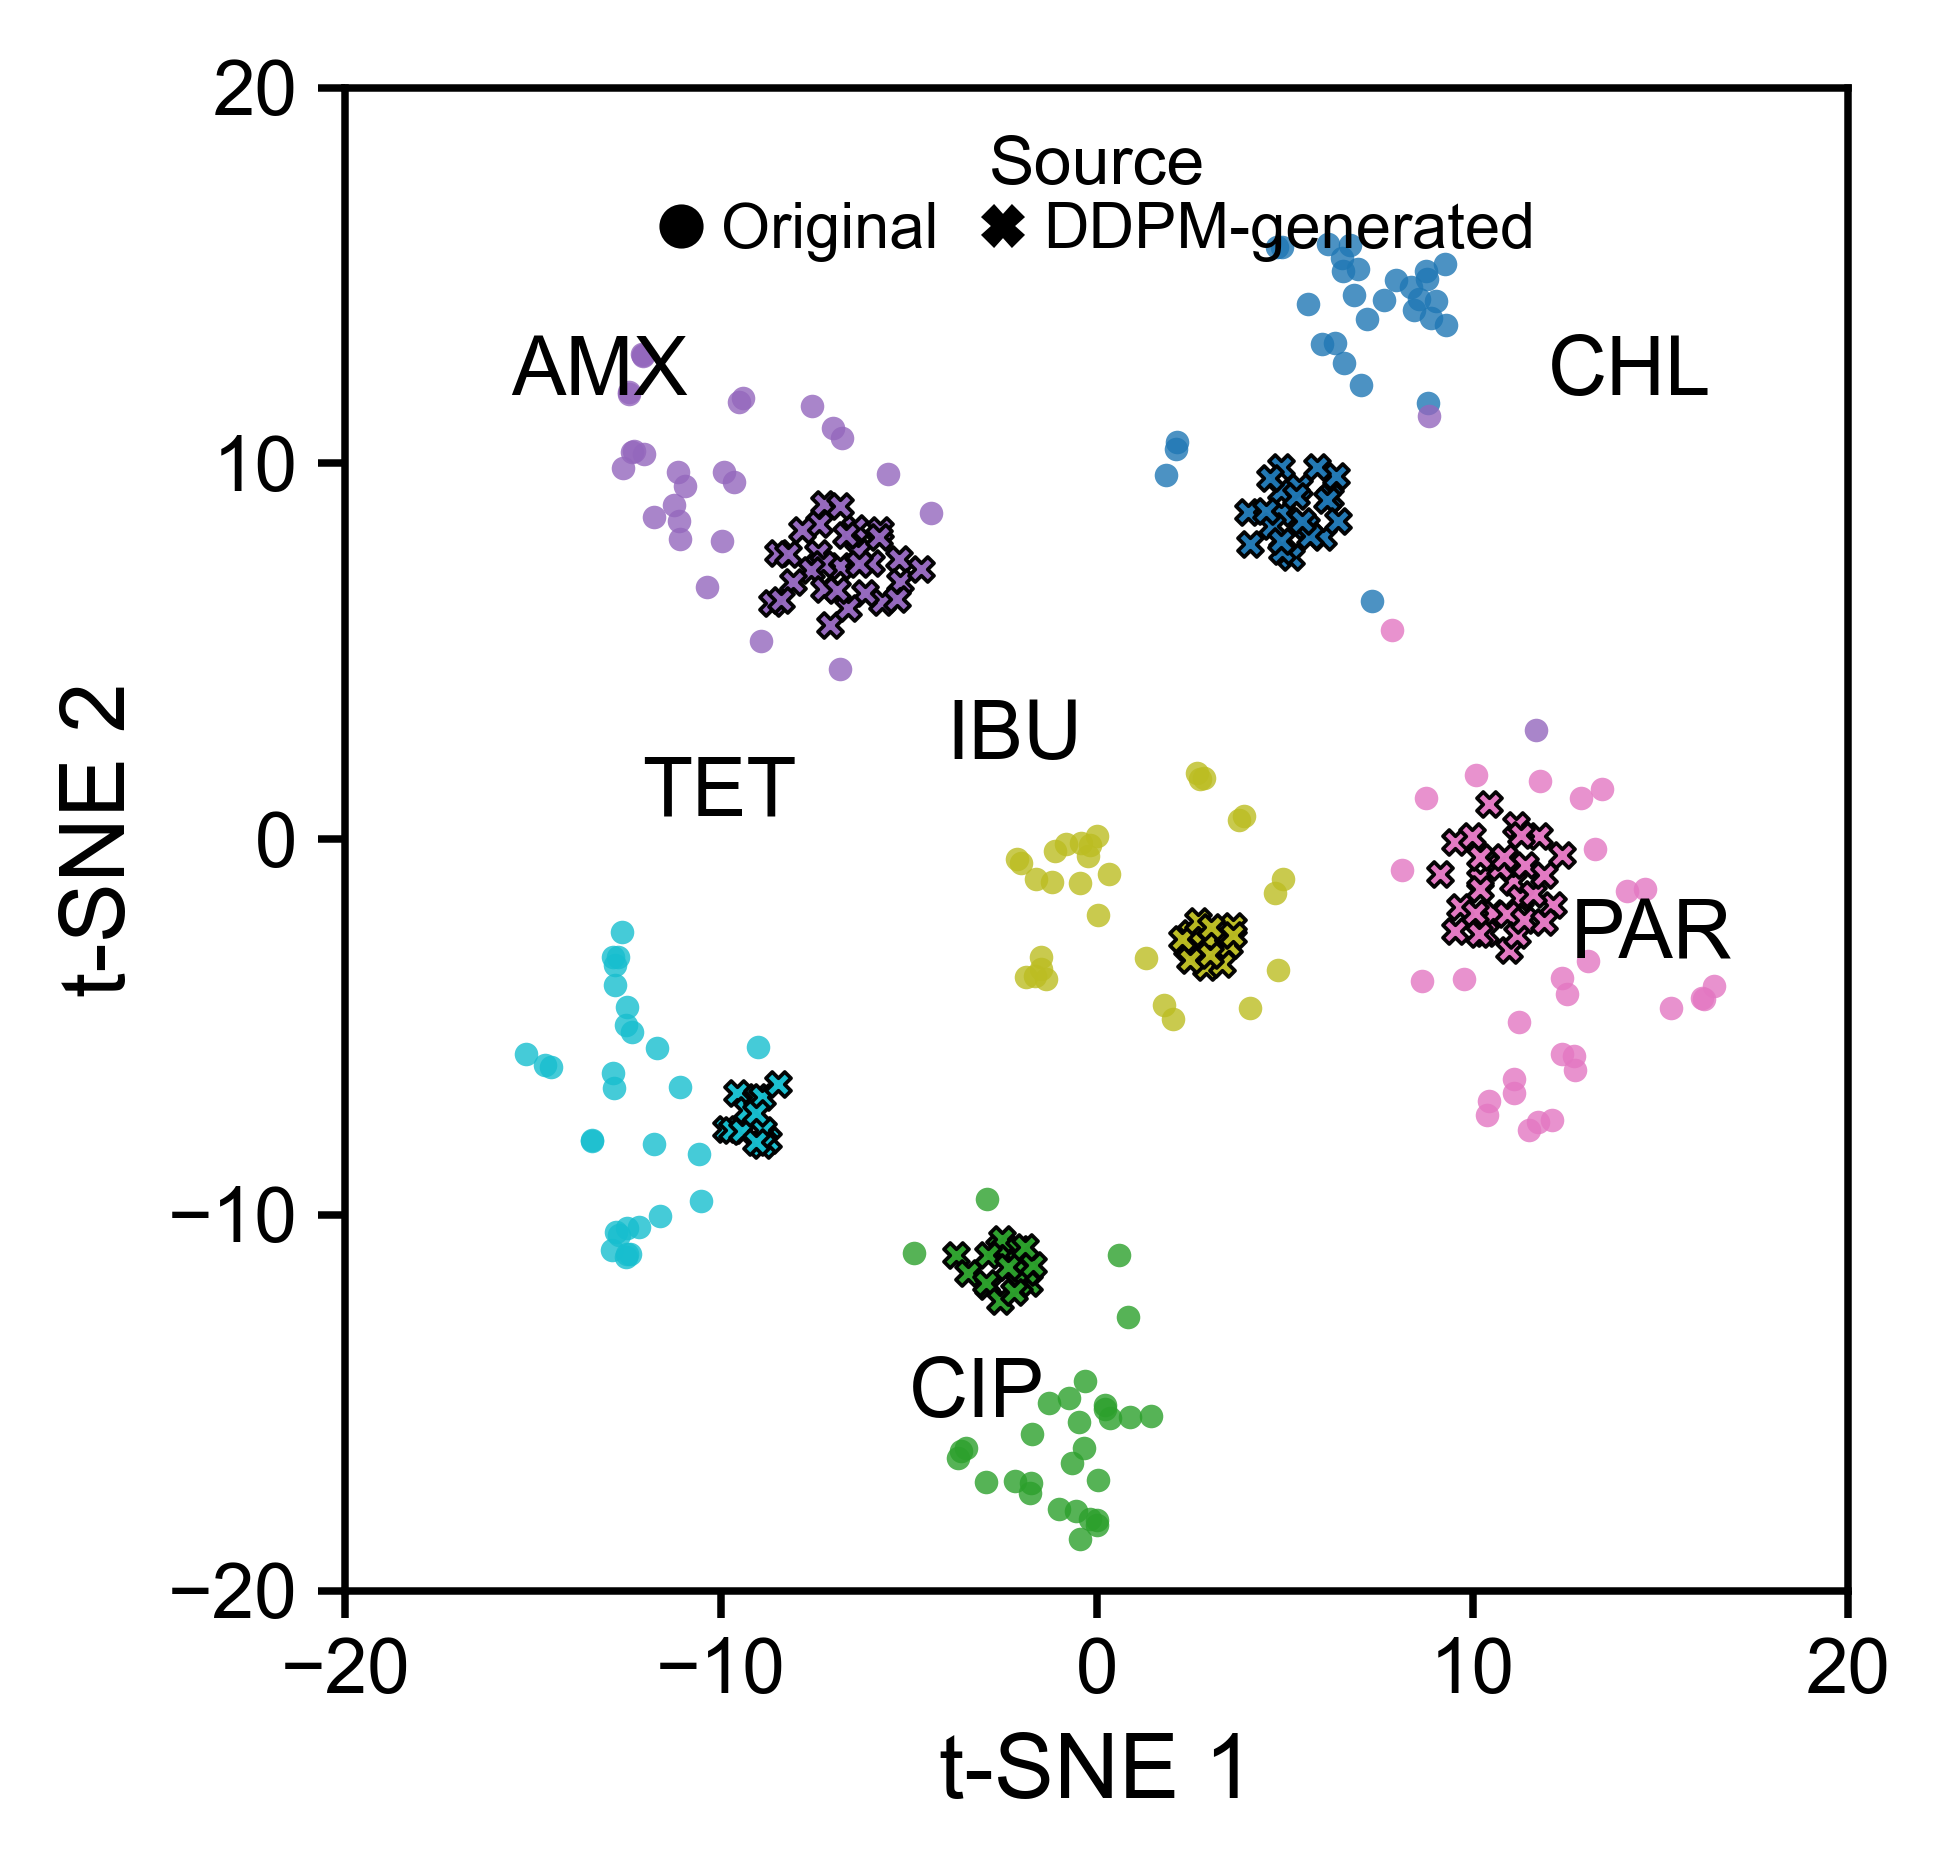

In [30]:
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.collections import PathCollection
from matplotlib.legend import Legend
from matplotlib.lines import Line2D

ROOT = PROJECT_ROOT / "models" / "abx_final_tuned"

fig, ax, info = P.plot_ddpm_tsne_real_vs_synthetic(
    root=ROOT,
    train_frac=0.25,
    pca_dim=64,
    ddpm_train_steps=4000,
    out_png=None,
    out_pdf=None,
    show=False,
    verbose=True,
)
# ============================================================
fig.set_size_inches(3.10, 3.00)
ax.set_title("")
ax.set_xlabel("t-SNE 1", fontsize=10.8, fontweight="normal", labelpad=3, fontfamily="Arial")
ax.set_ylabel("t-SNE 2", fontsize=10.8, fontweight="normal", labelpad=3, fontfamily="Arial")
ax.set_xlim(-20, 20)
ax.set_ylim(-20, 20)
ax.set_xticks([-20, -10, 0, 10, 20])
ax.set_yticks([-20, -10, 0, 10, 20])
ax.set_box_aspect(1)
ax.grid(False)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.9)
    spine.set_color("black")

ax.tick_params(axis="both", which="major",
               direction="out", top=False, right=False,
               length=3.2, width=0.9, labelsize=9.2, pad=2.5)

for t in ax.get_xticklabels() + ax.get_yticklabels():
    t.set_fontfamily("Arial")
    t.set_fontweight("normal")

fig.canvas.draw()

for c in ax.collections:
    if not isinstance(c, PathCollection):
        continue
    paths = c.get_paths()
    offs = c.get_offsets()
    if not paths or offs is None or len(offs) == 0:
        continue

    n_vertices = len(paths[0].vertices)
    is_ddpm = n_vertices <= 15   # X marker

    if is_ddpm:
        c.set_sizes([9.0])
        c.set_alpha(0.98)
        c.set_linewidths([0.45])
        c.set_edgecolors("black")
        c.set_zorder(4)
    else:
        c.set_sizes([8.0])
        c.set_alpha(0.80)
        c.set_linewidths([0.0])
        c.set_zorder(2)

for artist in ax.get_children():
    if isinstance(artist, Legend):
        artist.remove()

label_pos = {
    "AMX": (-15.6, 12.4, "left"),
    "TET": (-12.1,  1.2, "left"),
    "CIP": ( -5.0, -14.8, "left"),
    "IBU": ( -4.0,  2.7, "left"),
    "CHL": ( 12.0, 12.4, "left"),
    "PAR": ( 12.6, -2.6, "left"),
}

for name, (x, y, ha) in label_pos.items():
    ax.text(x, y, name,
            fontsize=9.8, fontweight="normal",
            fontfamily="Arial", color="black",
            ha=ha, va="center", zorder=10)

leg = ax.legend(
    handles=[
        Line2D([0], [0], marker="o", linestyle="None",
               color="black", markerfacecolor="black",
               markeredgecolor="black", markersize=4.3,
               label="Original"),
        Line2D([0], [0], marker="X", linestyle="None",
               color="black", markerfacecolor="black",
               markeredgecolor="black", markeredgewidth=0.50,
               markersize=4.5, label="DDPM-generated"),
    ],
    title="Source",
    loc="upper center",
    bbox_to_anchor=(0.50, 0.985),
    frameon=False,
    fontsize=7.6,
    title_fontsize=8.2,
    ncol=2,
    handlelength=0.72,
    handletextpad=0.28,
    columnspacing=0.65,
    labelspacing=0.08,
    borderaxespad=0.0,
)

for txt in leg.get_texts():
    txt.set_fontfamily("Arial")
    txt.set_fontweight("normal")
leg.get_title().set_fontfamily("Arial")
leg.get_title().set_fontweight("normal")

fig.subplots_adjust(left=0.17, right=0.985, bottom=0.15, top=0.985)

# save
stem = ROOT / "tsne_original_ddpm_RIGHT_STYLE"

fig.savefig(stem.with_suffix(".png"), dpi=900, bbox_inches="tight", pad_inches=0.012, facecolor="white")
fig.savefig(stem.with_suffix(".pdf"), bbox_inches="tight", pad_inches=0.012, facecolor="white")
fig.savefig(stem.with_suffix(".svg"), bbox_inches="tight", pad_inches=0.012, facecolor="white")
fig.savefig(stem.with_suffix(".tiff"), dpi=600, bbox_inches="tight", pad_inches=0.012,
            facecolor="white", pil_kwargs={"compression": "tiff_lzw"})

plt.show()